In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import os

In [14]:
df = pd.read_csv("DO-NOT-DISTRIBUTE-KODIS-human-human-subset.csv")
df.rename(columns={df.columns[0]: "kodis-id"}, inplace=True)

# filter only conversations that end with "Accept Deal"
resolved_convos_df = df[df["b_fullChat"].str.contains(r"Accept Deal<br>", regex=True, na=False)]
resolved_convos_df[["kodis-id", "b_fullChat"]].to_csv("resolved_conversations.csv", index=False)

# The length of this is 191 Conversations, the expected value
# print(resolved_convos_df)

In [15]:
kodis_personality_df = pd.read_csv("KODIS_personality.csv")

def categorize_score(score):
    if 1.0 <= score <= 2.0:
        return "Low"
    elif 2.5 <= score <= 3.5:
        return "Medium"
    elif 4.0 <= score <= 5.0:
        return "High"
    return "Out of Range"  

personality_traits = [
    "extroversion_score",
    "agreeableness_score",
    "conscientiousness_score",
    "neuroticism_score",
    "openness_score"
]

personality_scores = ["Low", "Medium", "High"]

for col in personality_columns:
    kodis_personality_df[col] = kodis_personality_df[col].apply(categorize_score)


kodis_personality_df.to_csv("kodis_personality_categorized.csv")

# Sanity check
# print(kodis_personality_df)

In [16]:
liwc_categories = {
    "i": "First Person Singular",
    "we": "First Person Plural", 
    "you": "Second Person",
    "tone_pos": "Positive Tone",
    "tone_neg": "Negative Tone",
    "polite": "Politeness", 
    "conflict": "Interpersonal Conflict"
}

# load respective CSVs
resolved_convos_df = pd.read_csv("resolved_conversations.csv")  
kodis_personality_df = pd.read_csv("kodis_personality_categorized.csv")

# temporal analysis
liwc_turns_df = pd.read_csv("LIWC_22_Temporal_K-3.csv")

# calculate the 'turns' column by grouping the kodis-id & buyer or seller
liwc_turns_df['turns'] = liwc_turns_df.groupby(['kodis-id', 'buyer or seller']).cumcount() + 1

# get the kodis IDs of the resolved conversations
resolved_kodis_ids = resolved_convos_df["kodis-id"].unique()

# filter the new LIWC data to include only rows with resolved kodis IDs
filtered_liwc_turns_df = liwc_turns_df[liwc_turns_df['kodis-id'].isin(resolved_kodis_ids)]
filtered_liwc_turns_df.to_csv("respective_filtered_turns.csv", index=False)

# Sanity check
# print("filtered columns:", filtered_liwc_turns_df.columns)

merged_df = pd.merge(filtered_liwc_turns_df, kodis_personality_df, on=["kodis-id", "buyer or seller"], how="left")

buyer_data = merged_df[merged_df["buyer or seller"].str.lower() == "buyer"].copy()
seller_data = merged_df[merged_df["buyer or seller"].str.lower() == "seller"].copy()

# print("Buyer columns:", buyer_data.columns)
# print("Seller columns:", seller_data.columns)


In [17]:
def plot_liwc(liwc_variable, personality_scores, buyer_data, seller_data, personality_traits):
    if liwc_variable not in buyer_data.columns or liwc_variable not in seller_data.columns:
        raise ValueError(f"'{liwc_variable}' is not found in data columns.")
    
    for trait in personality_traits:
        plt.figure(figsize=(10, 6))
        for level in personality_scores:
            # filter data for the current personality trait and level.
            filtered_buyer = buyer_data[buyer_data[trait] == level]
            filtered_seller = seller_data[seller_data[trait] == level]
            
            if not filtered_buyer.empty:
                buyer_avg = filtered_buyer.groupby('turns')[liwc_variable].mean().reset_index()
            else:
                buyer_avg = None
            if not filtered_seller.empty:
                seller_avg = filtered_seller.groupby('turns')[liwc_variable].mean().reset_index()
            else:
                seller_avg = None
            
            # TO DO: Seperate the Buyer / Seller. Need to create TWO seperate 
            if seller_avg is not None:
                plt.plot(seller_avg['turns'], seller_avg[liwc_variable], color="blue", 
                         marker='o', label="Seller Average")
            if buyer_avg is not None:
                plt.plot(buyer_avg['turns'], buyer_avg[liwc_variable], color="red", 
                         marker='o', label="Buyer Average")
            
            plt.xlabel("Turn")
            plt.ylabel(liwc_categories.get(liwc_variable, liwc_variable))
            plt.title(f"Average {liwc_categories.get(liwc_variable, liwc_variable)} \nfor {level} {trait}")
            plt.legend(loc="lower right")
            plt.grid(True)
            
            combined_save_dir = f"Final/{liwc_categories.get(liwc_variable, liwc_variable)}"
            os.makedirs(combined_save_dir, exist_ok=True)
            combined_save_path = os.path.join(combined_save_dir, f"{level}_{trait}_combined.png")
            plt.savefig(combined_save_path, bbox_inches="tight", dpi=300)
            
            plt.show()
            plt.close()
            
            

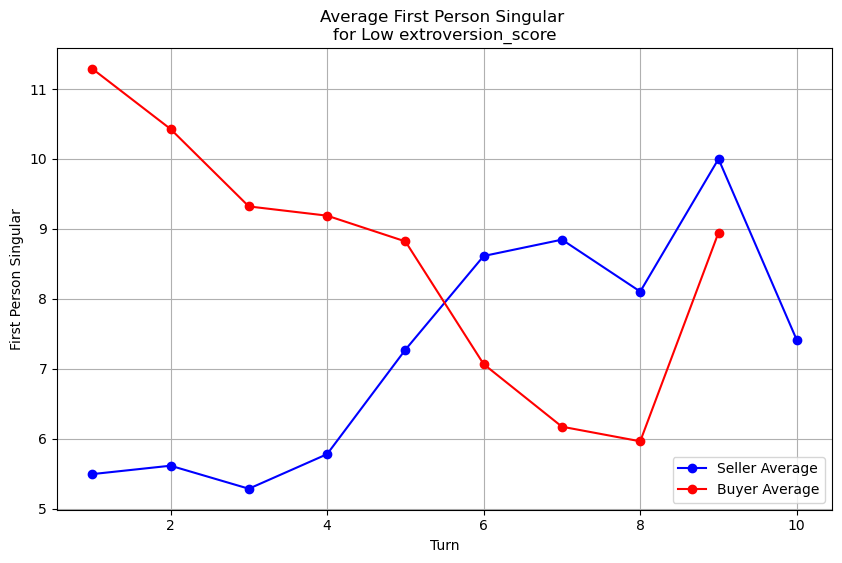

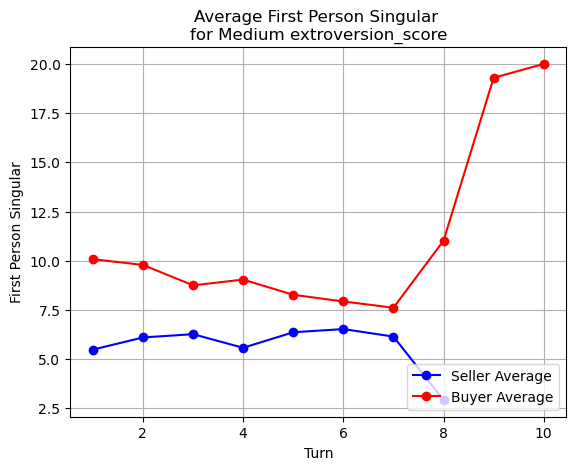

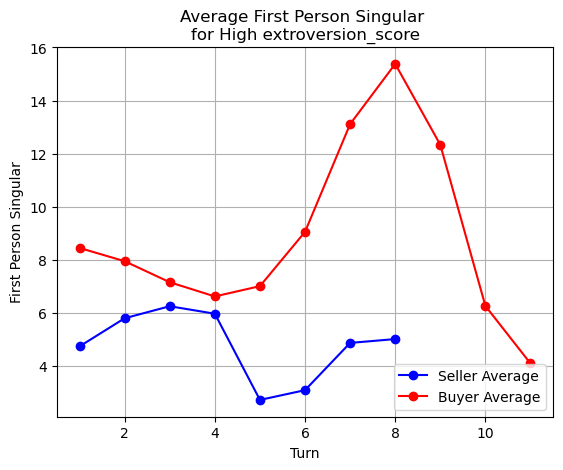

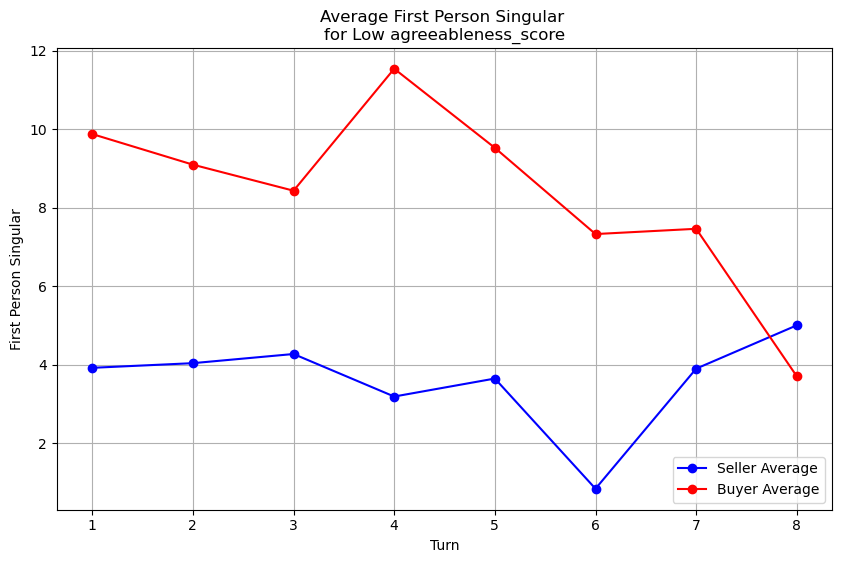

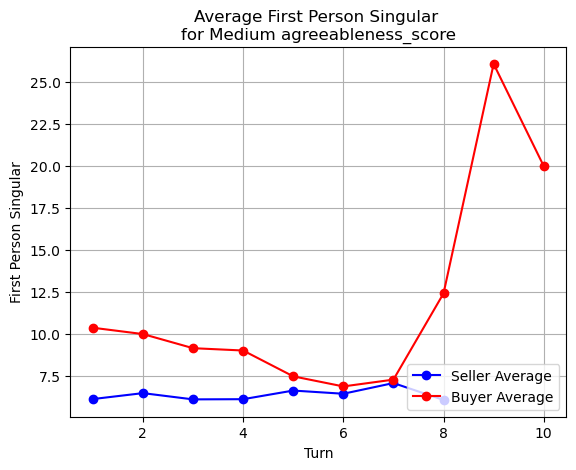

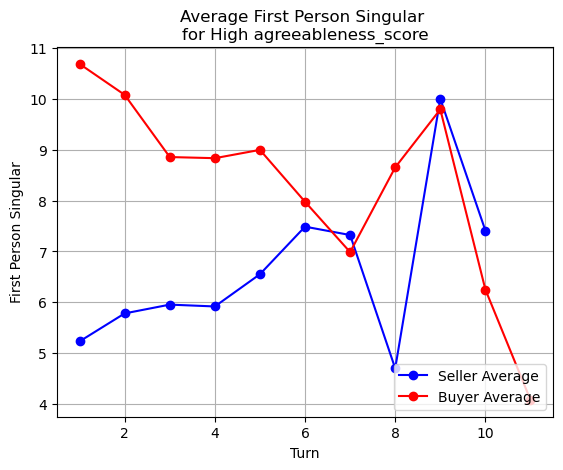

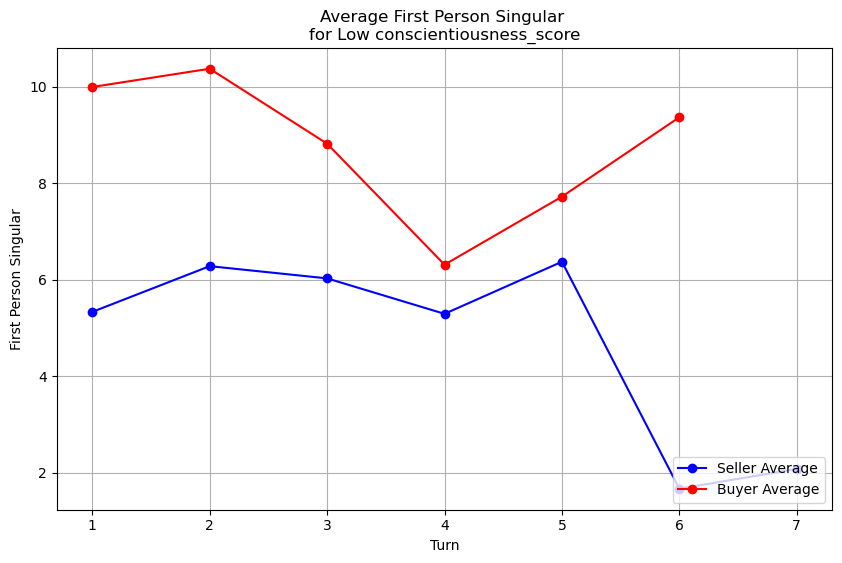

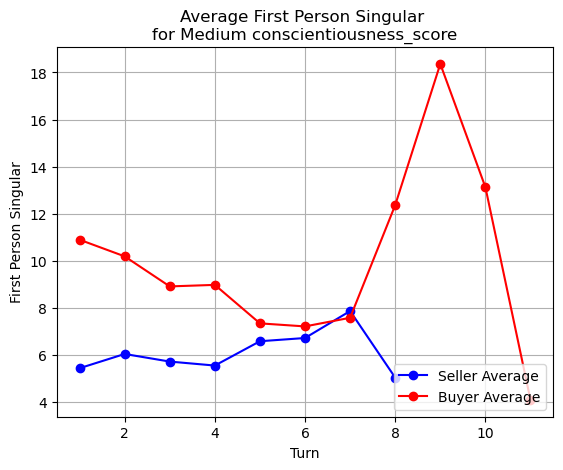

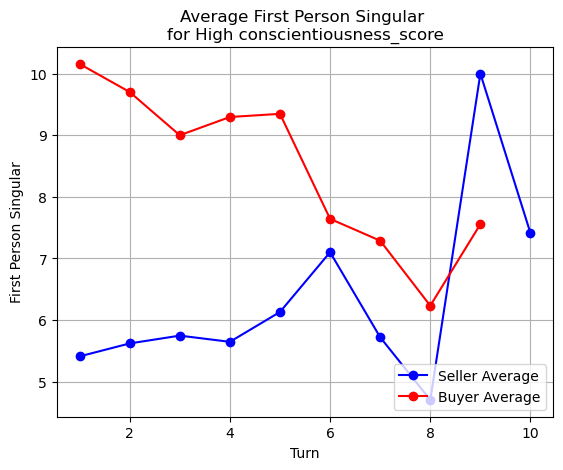

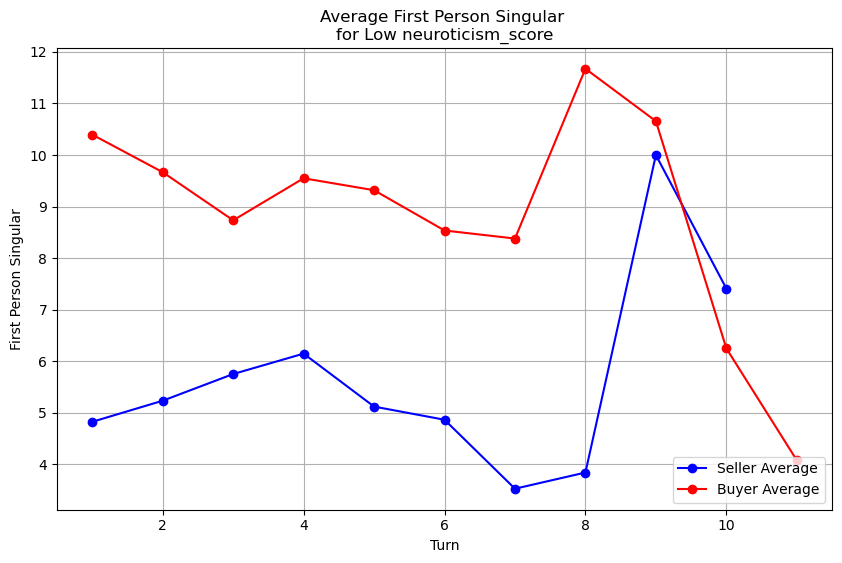

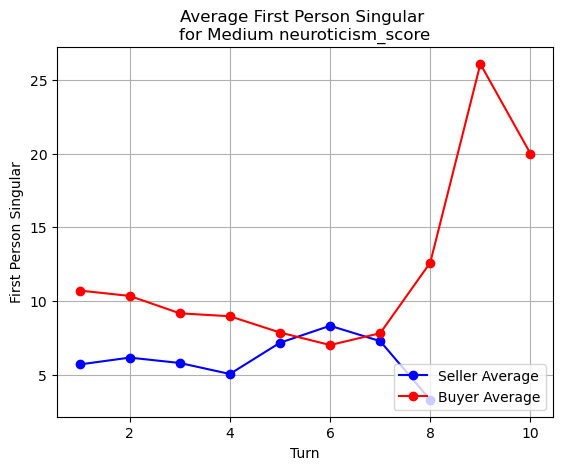

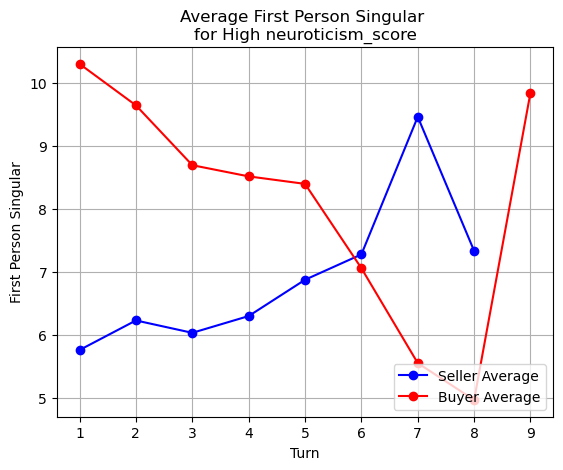

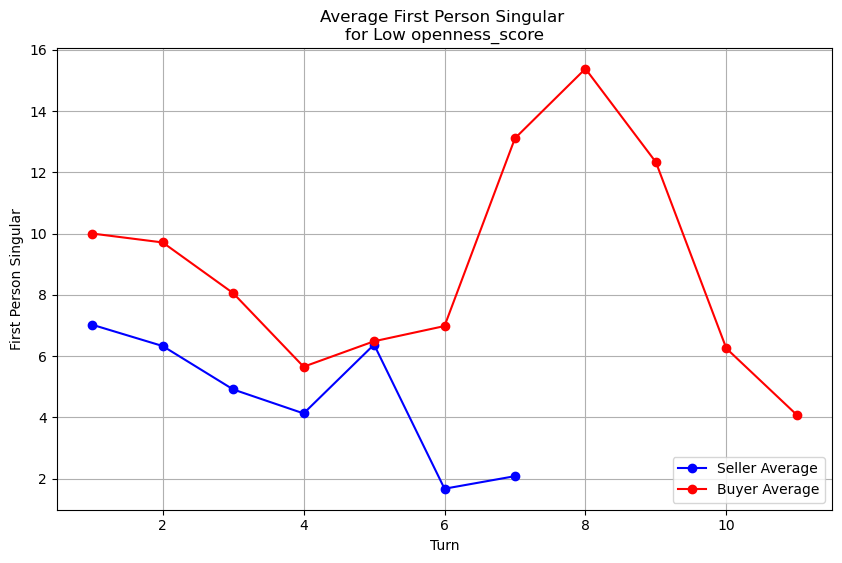

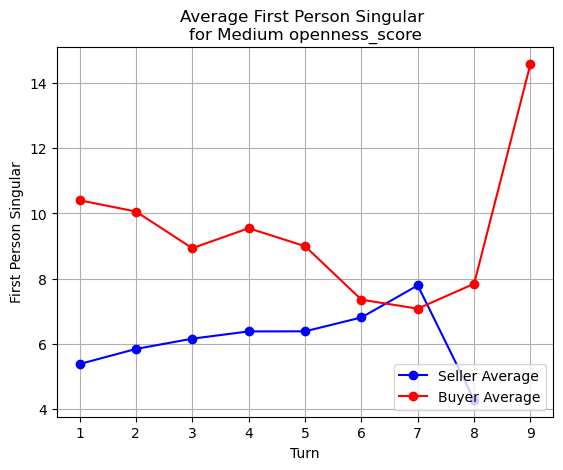

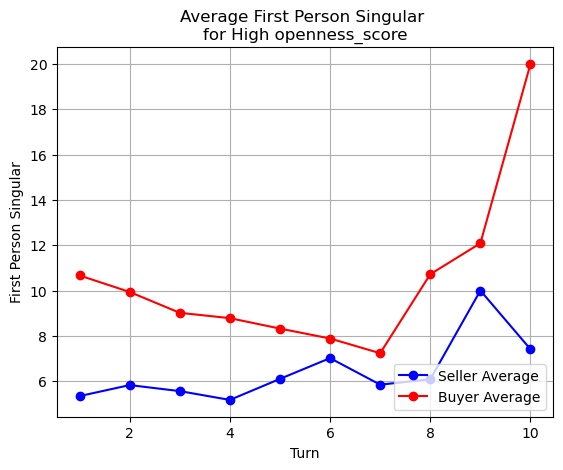

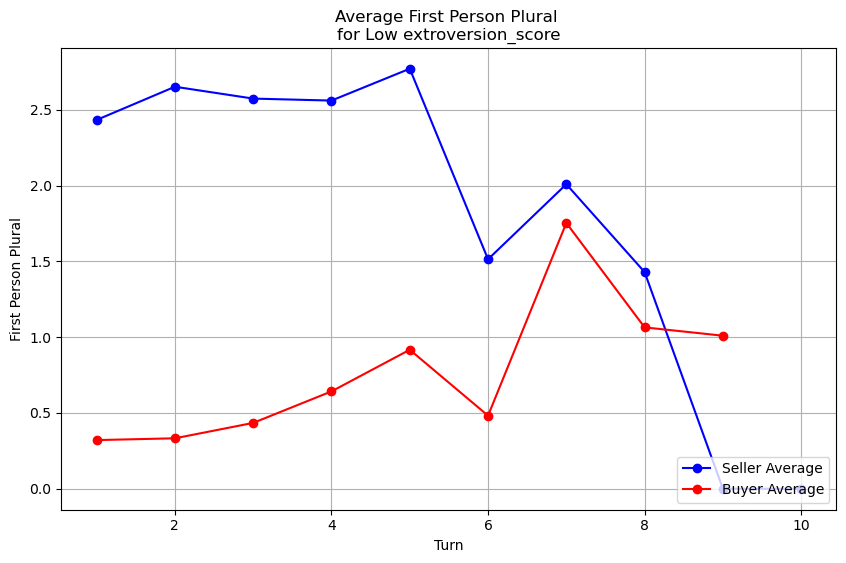

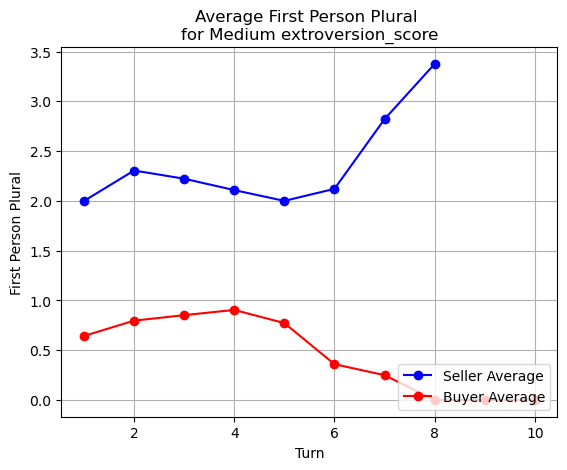

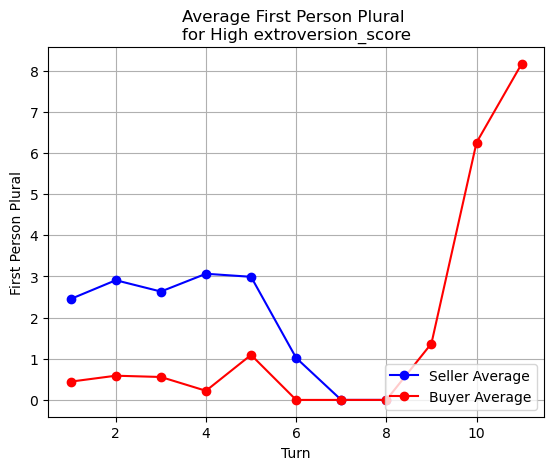

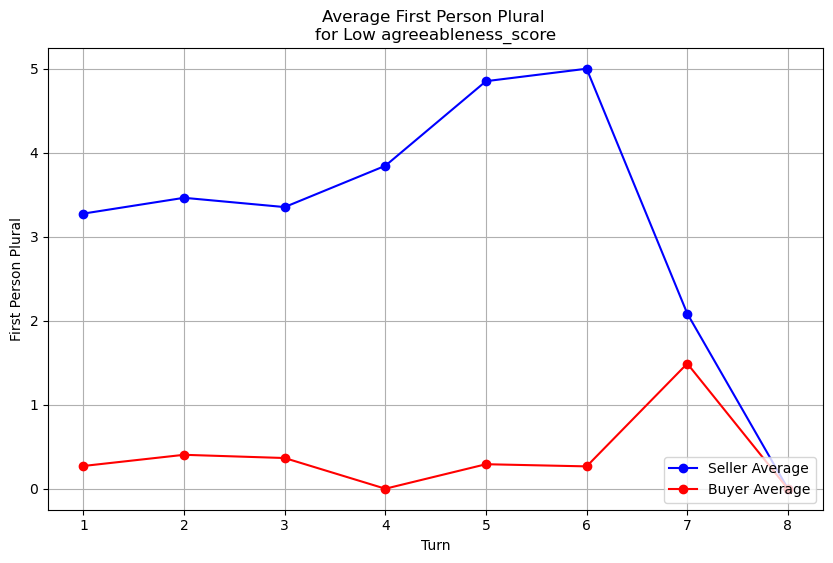

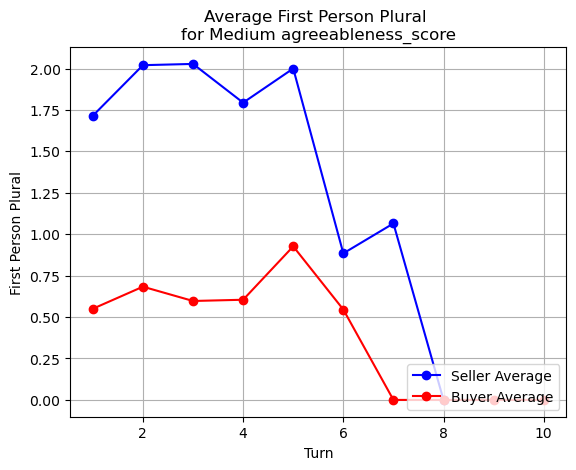

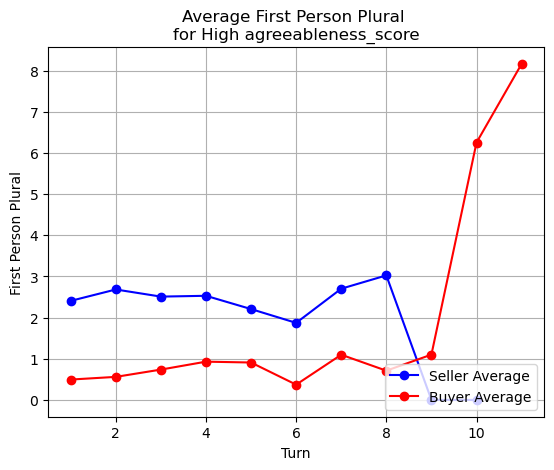

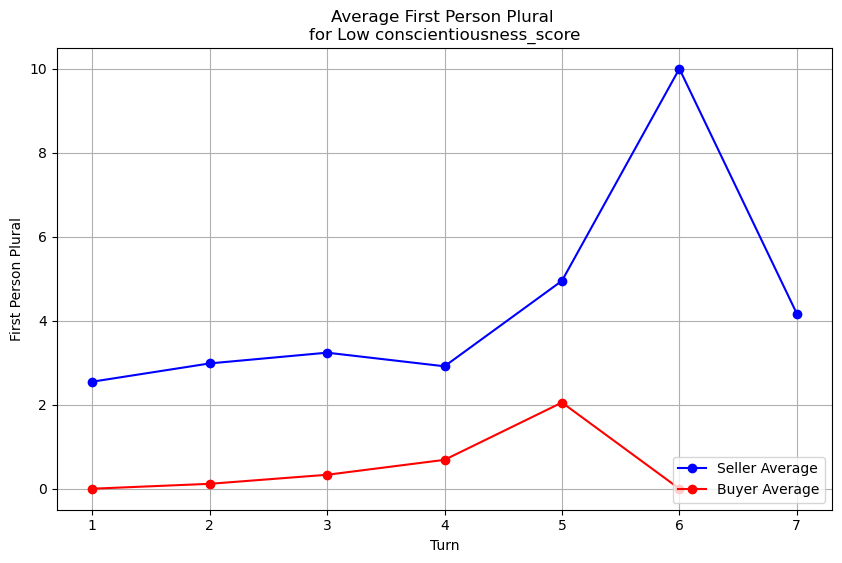

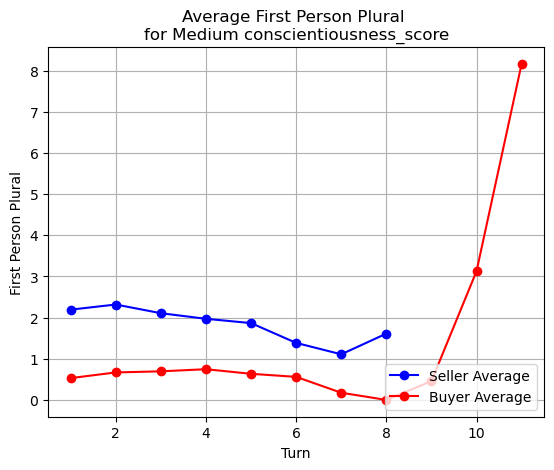

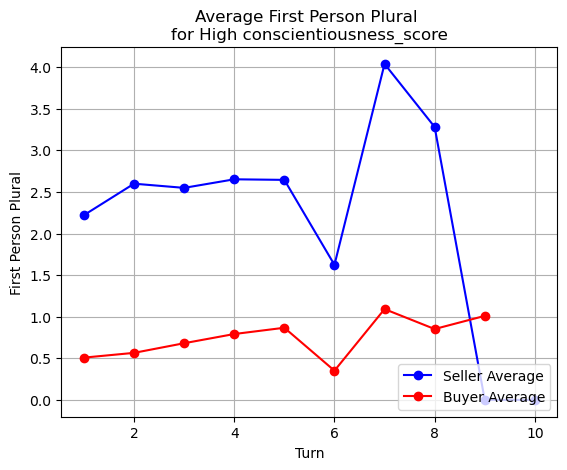

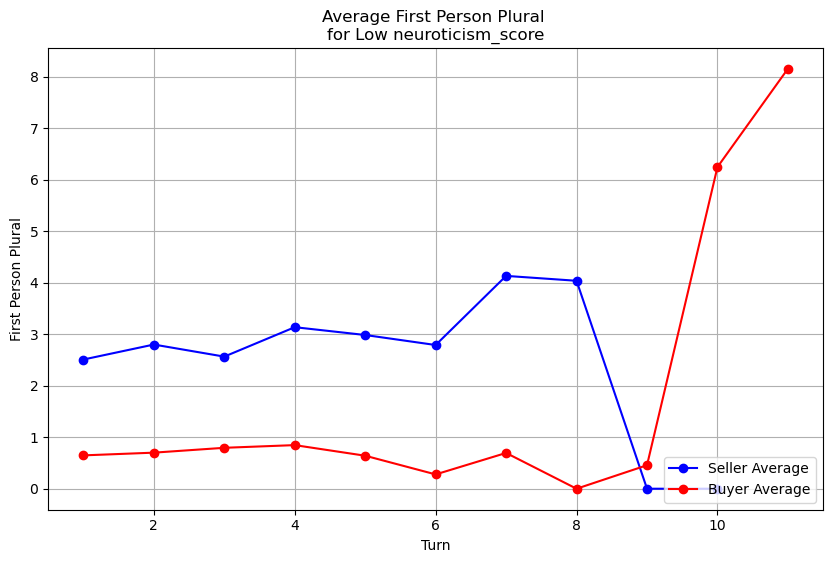

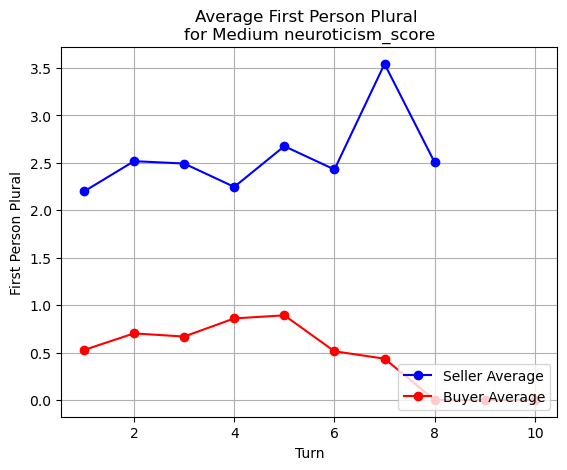

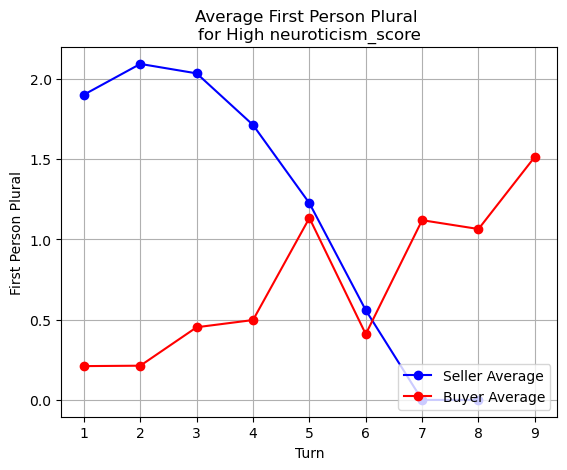

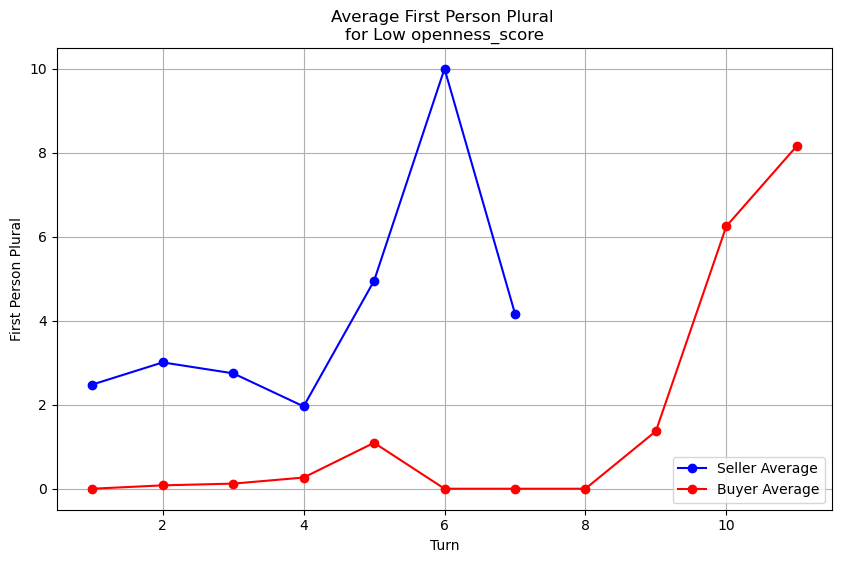

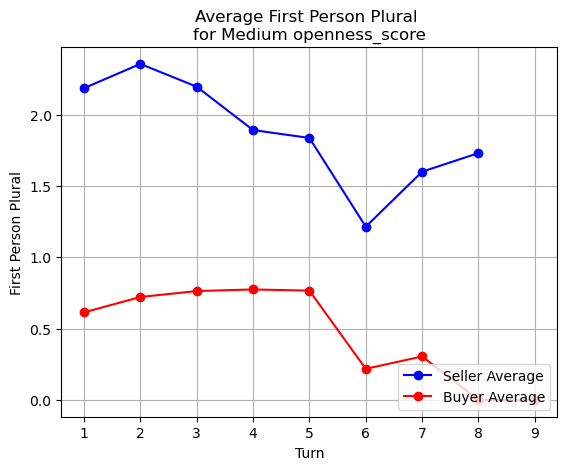

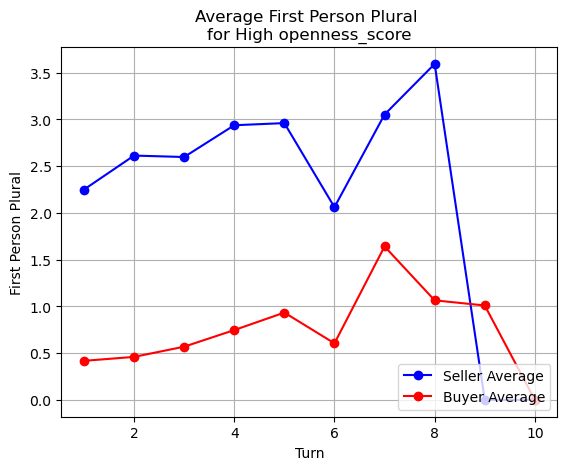

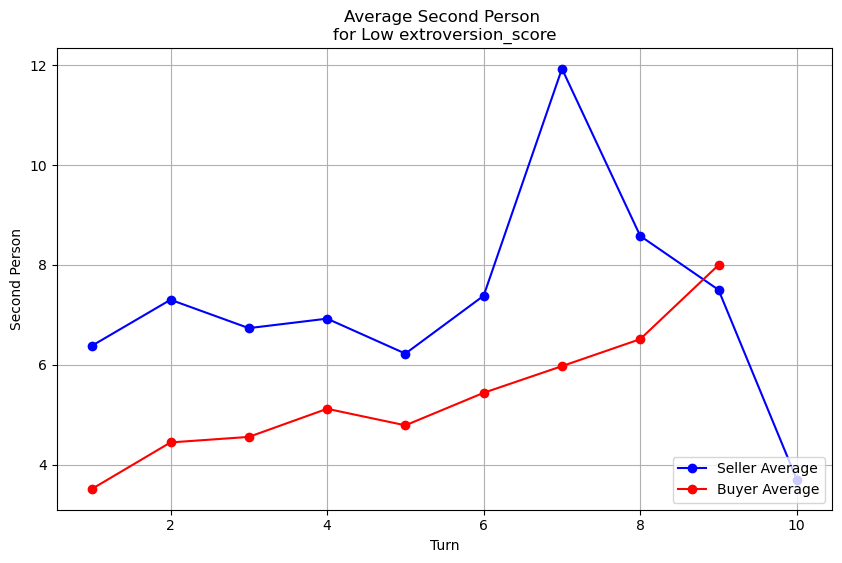

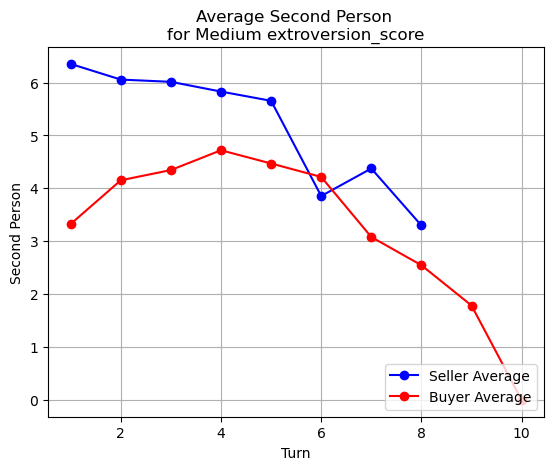

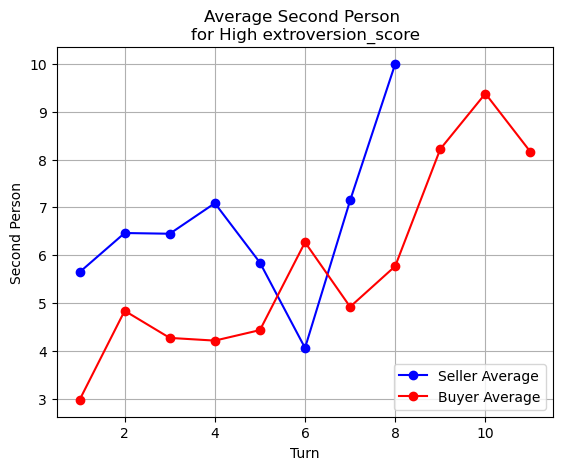

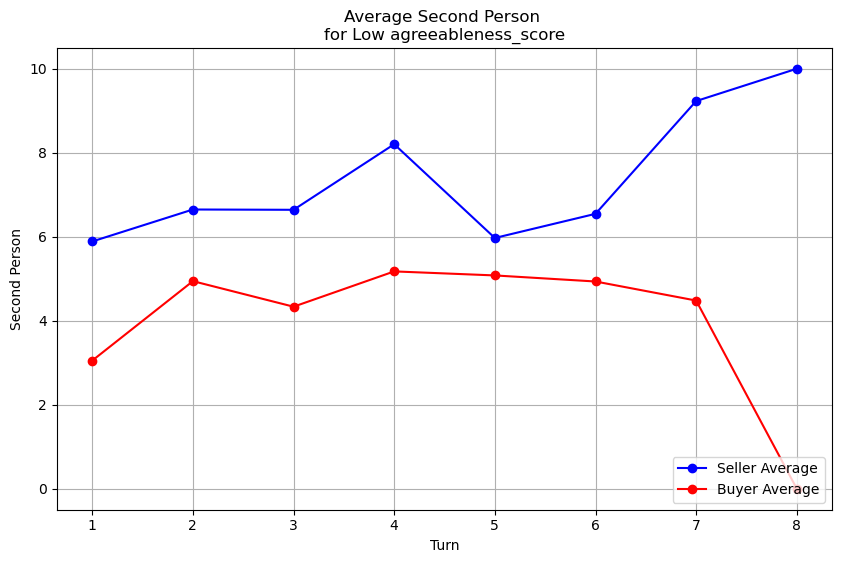

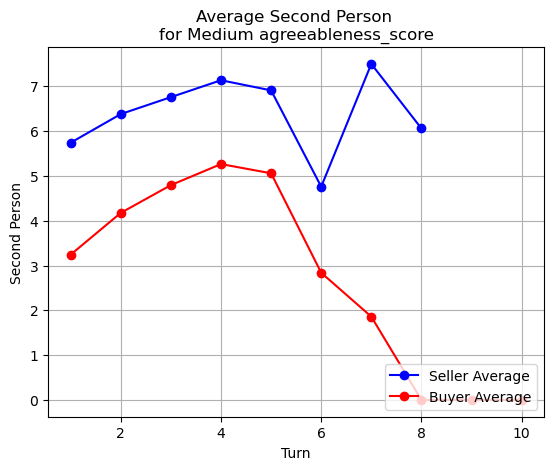

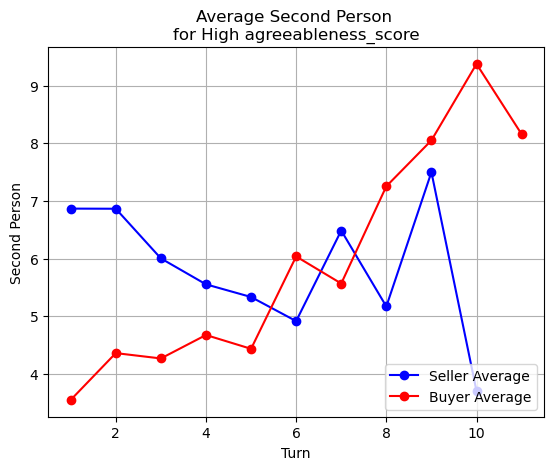

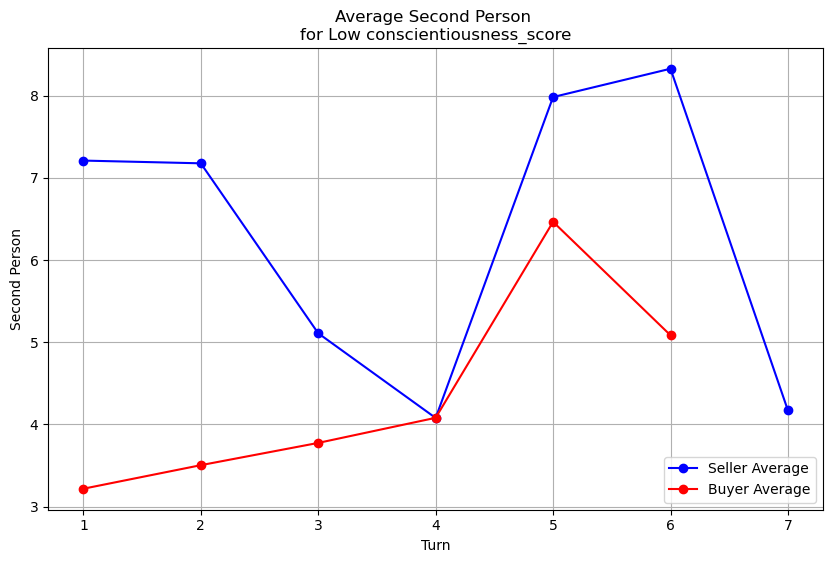

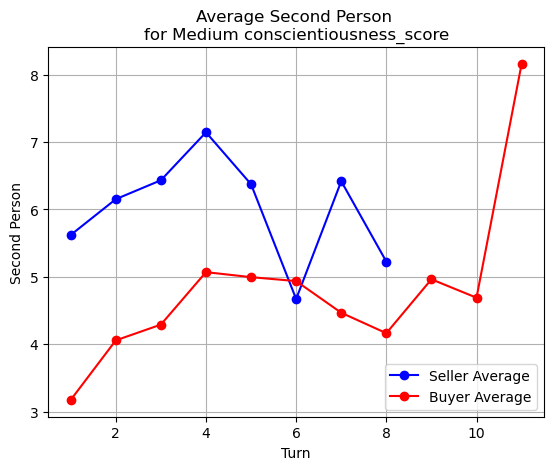

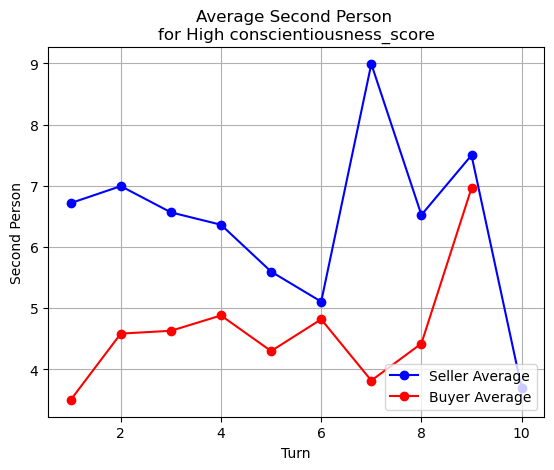

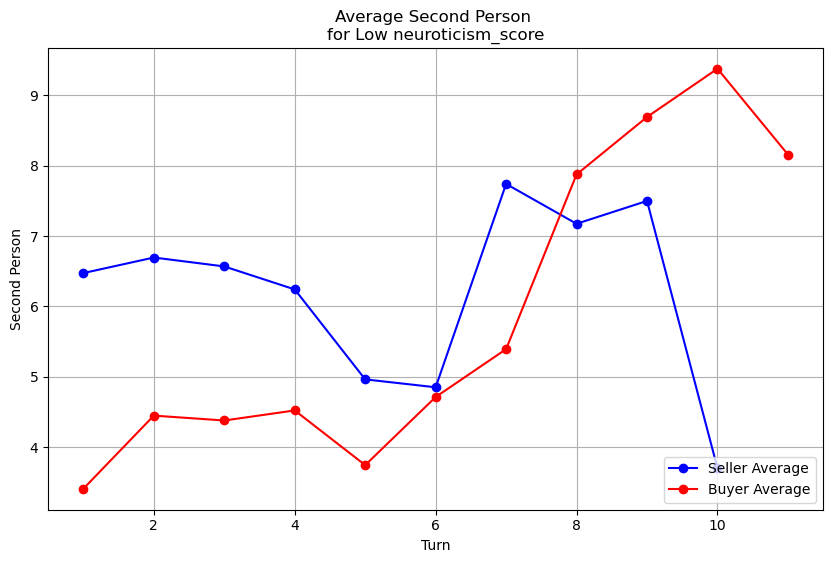

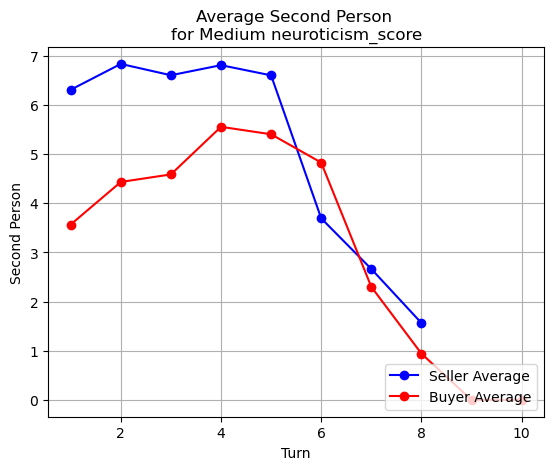

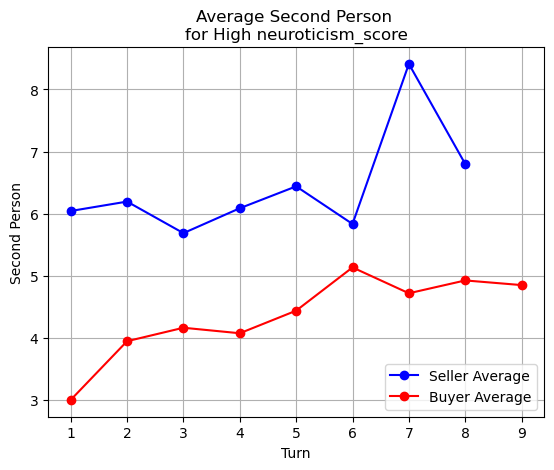

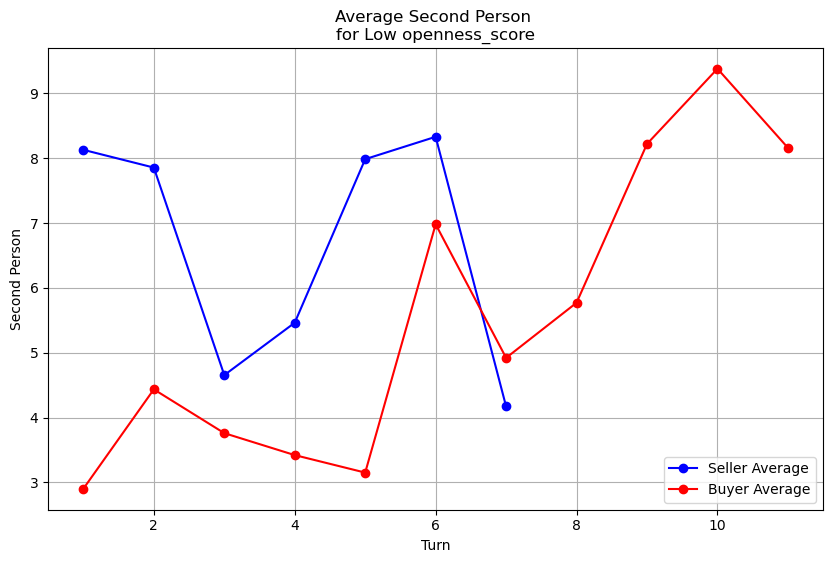

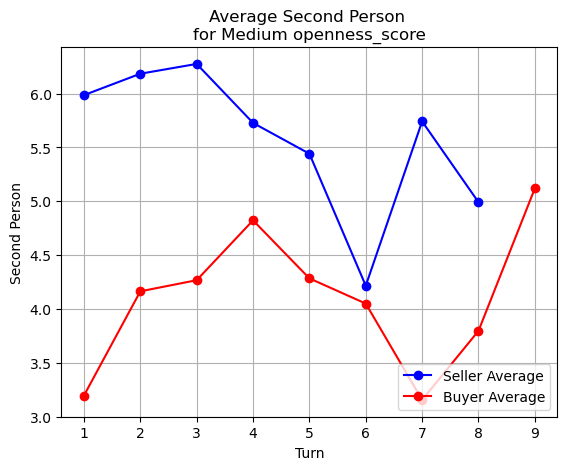

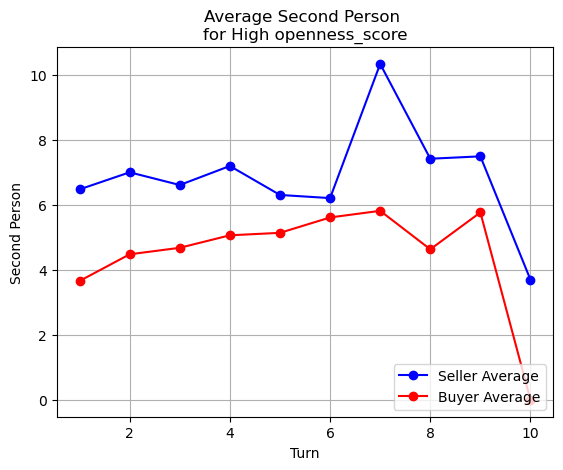

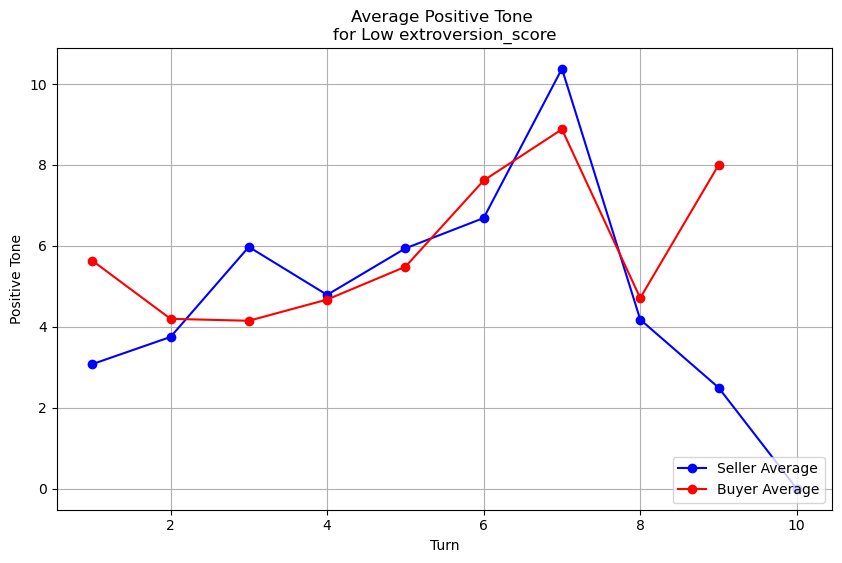

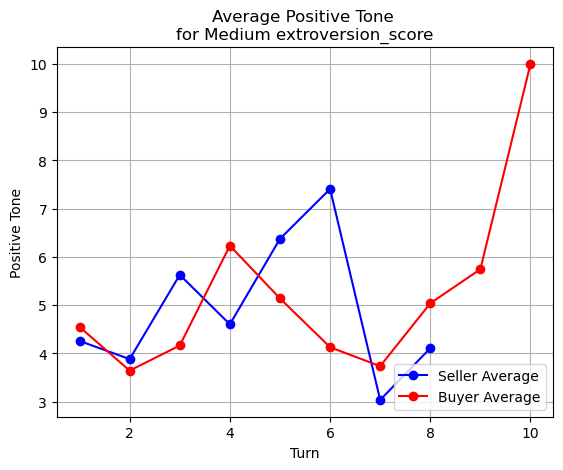

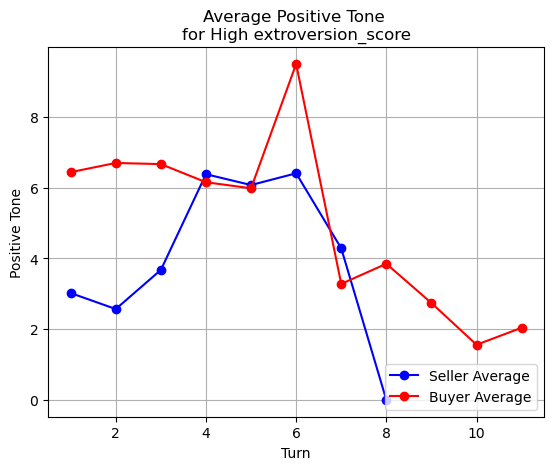

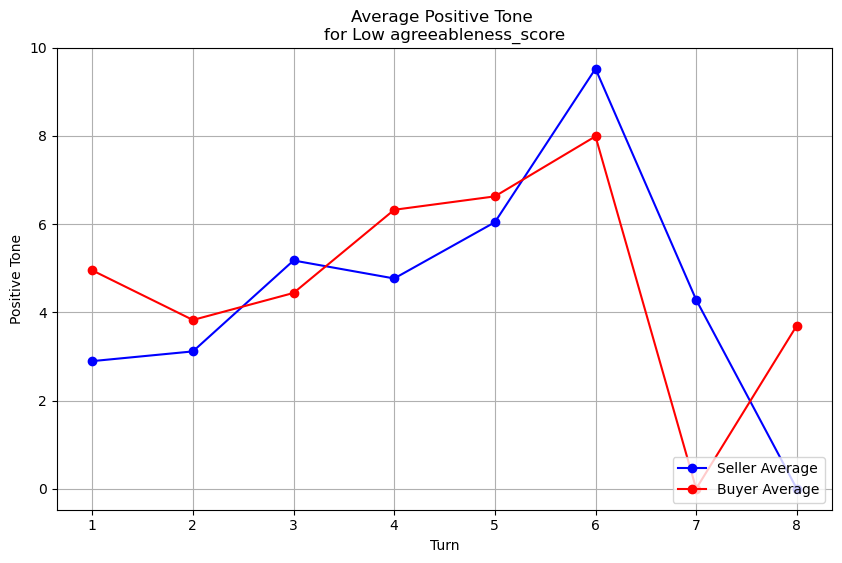

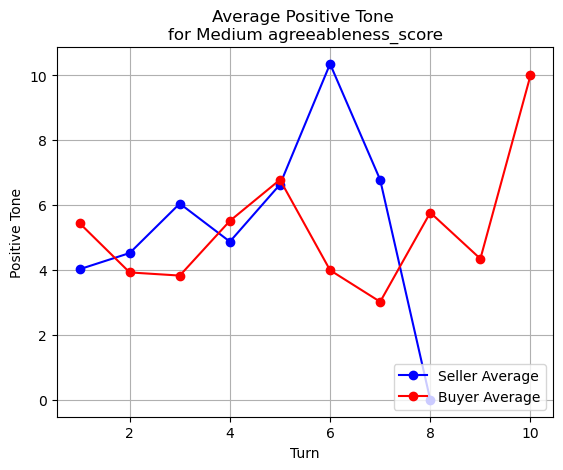

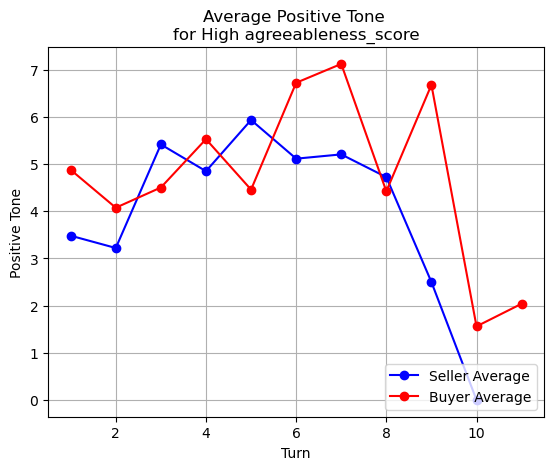

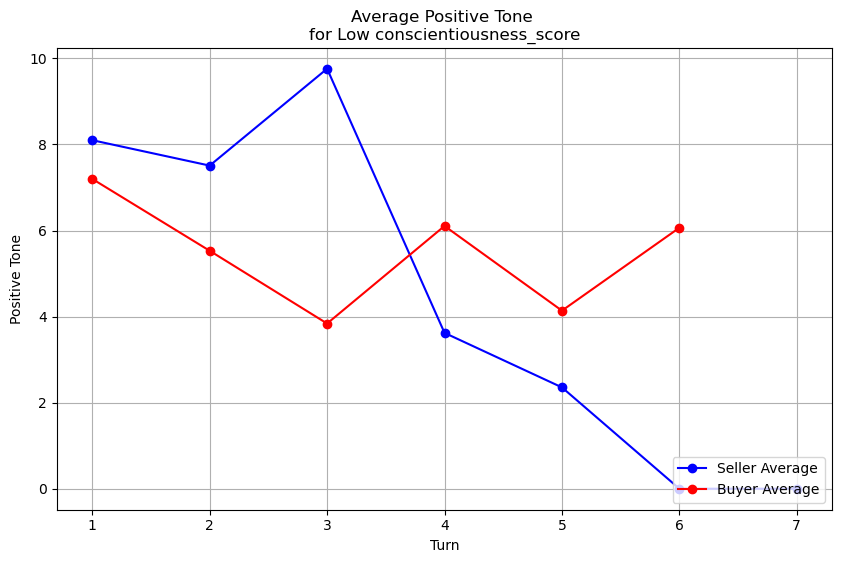

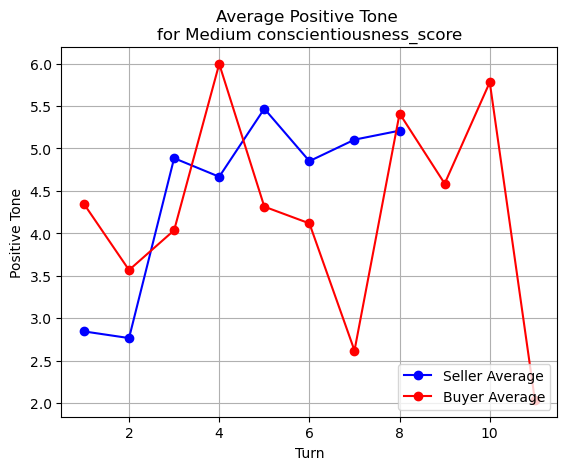

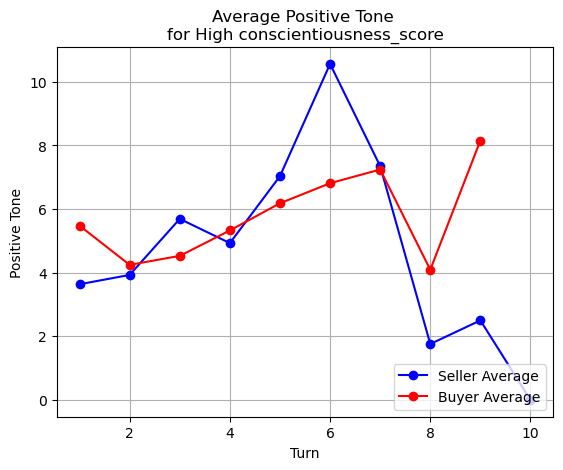

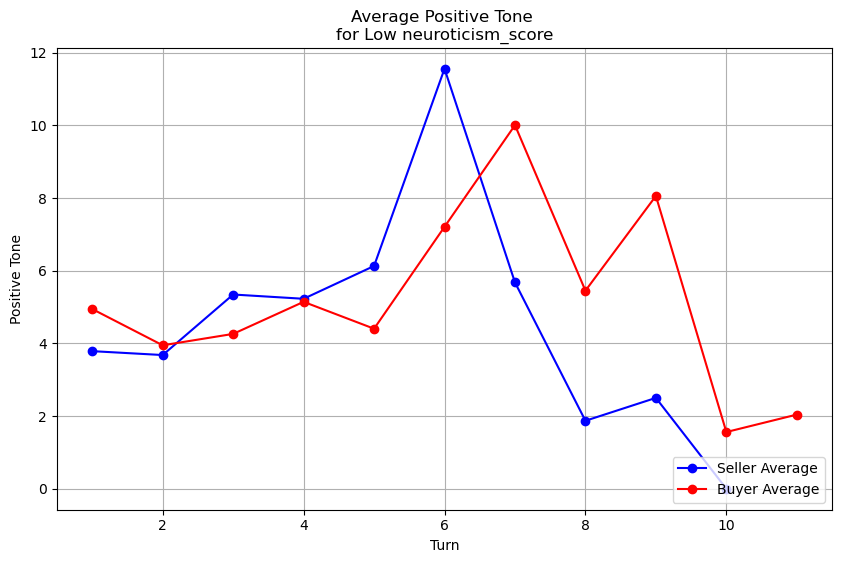

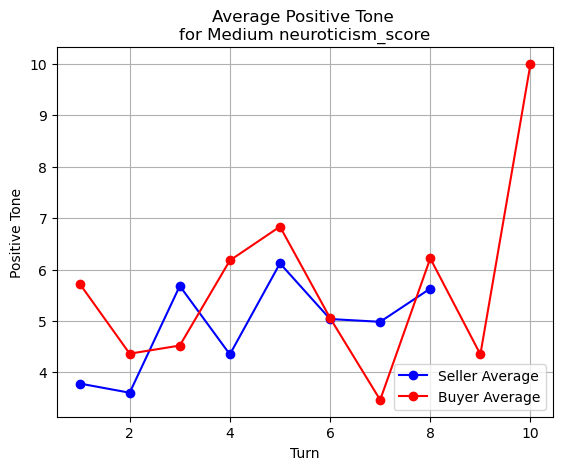

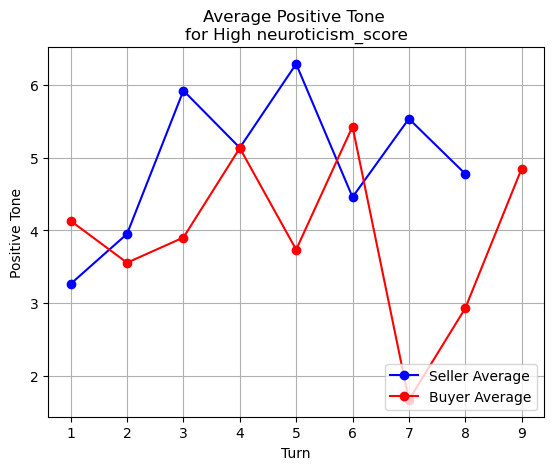

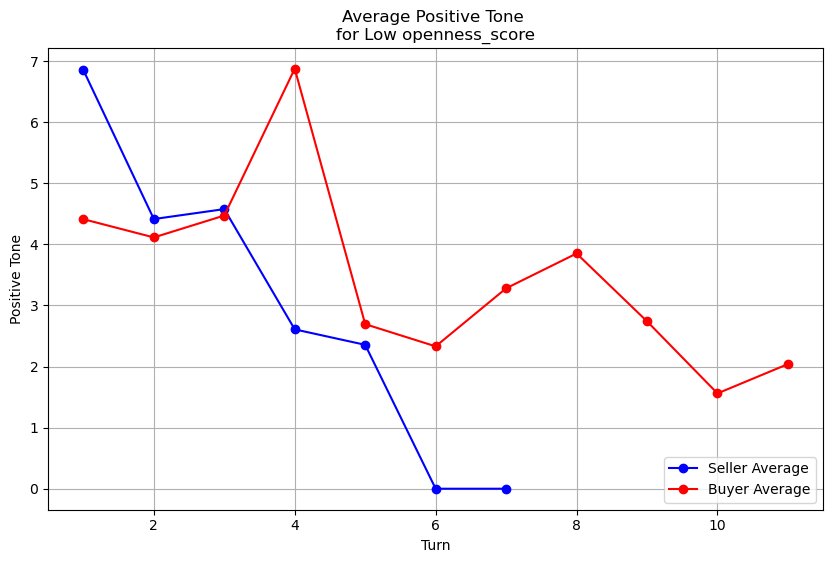

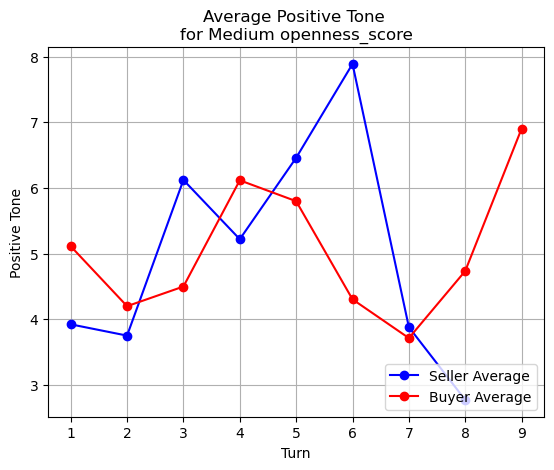

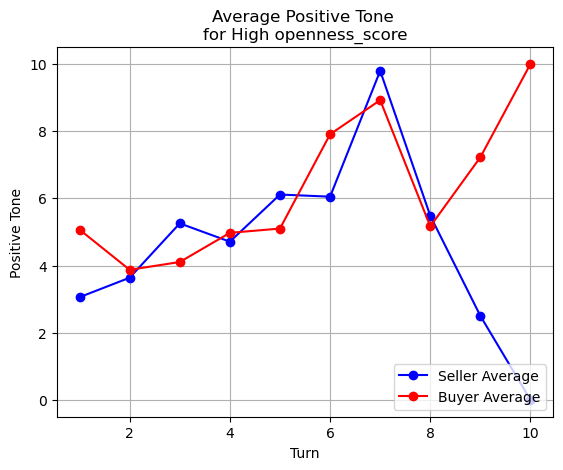

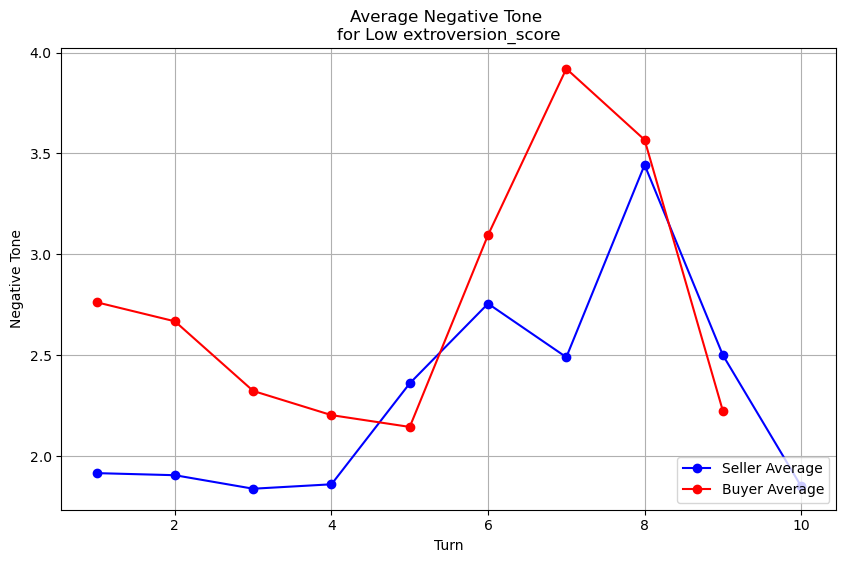

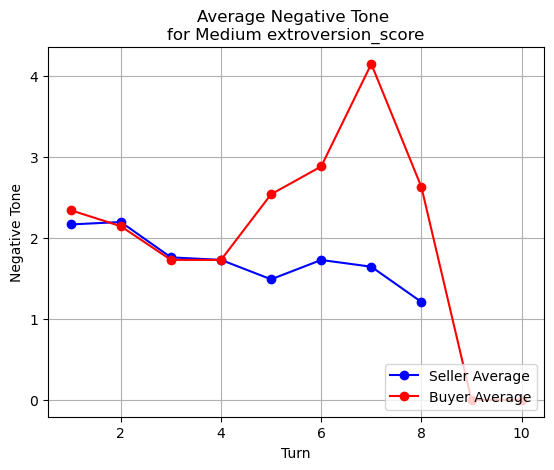

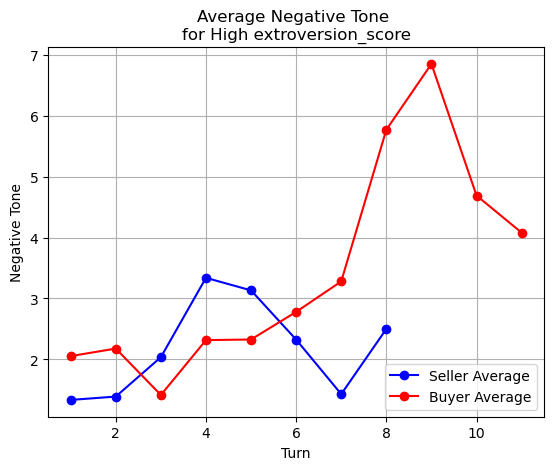

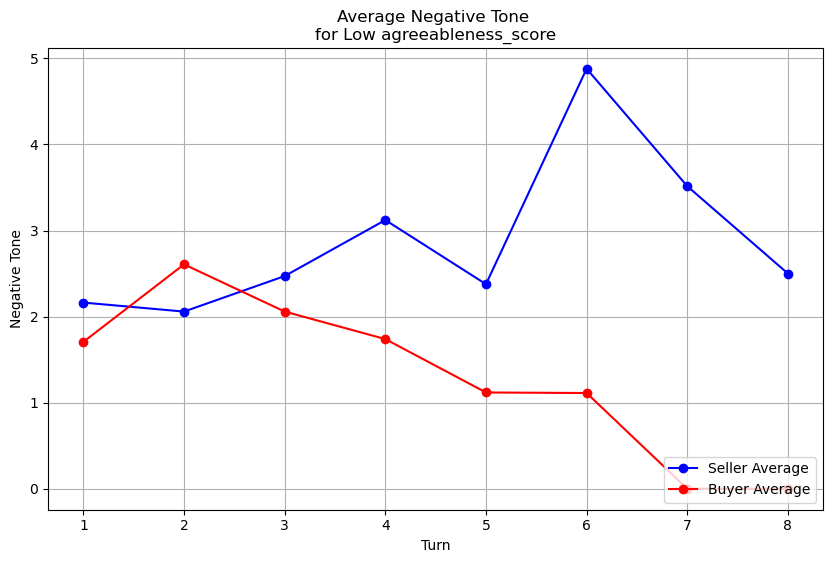

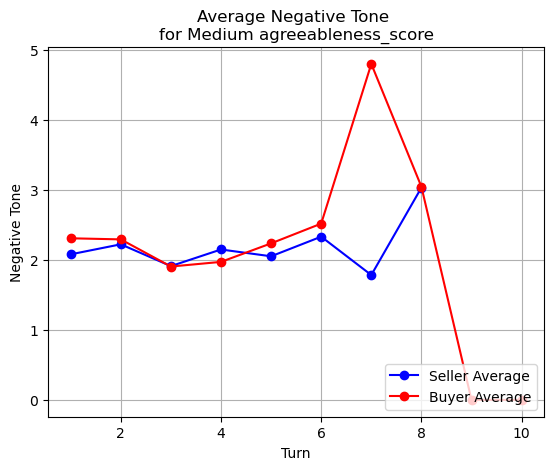

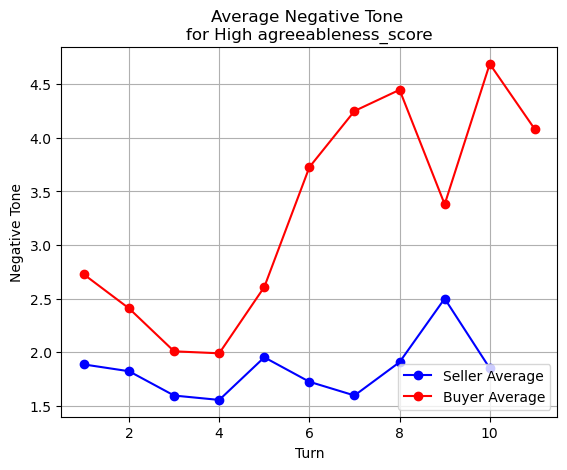

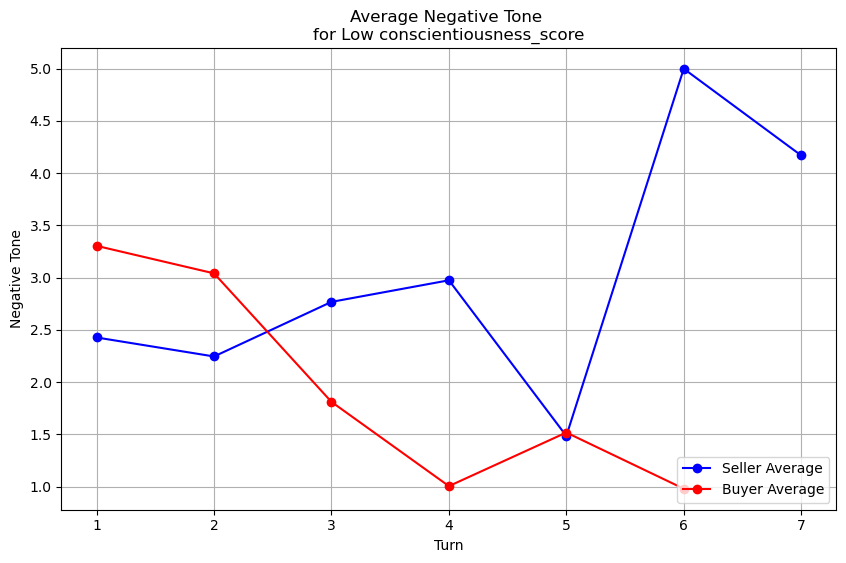

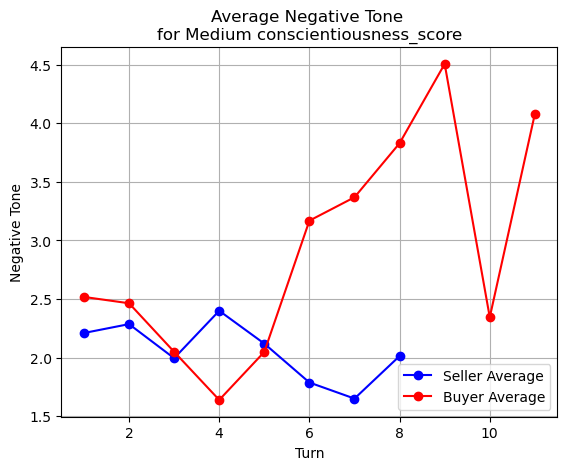

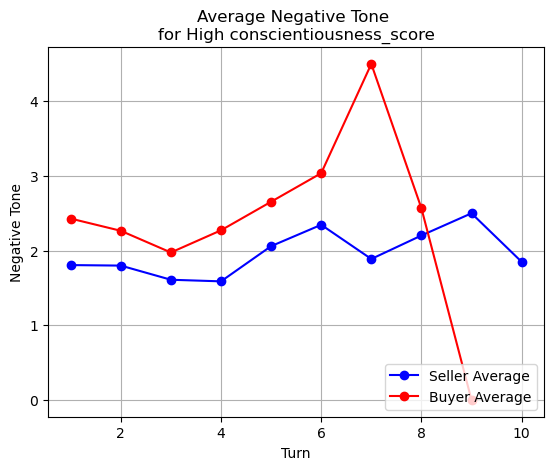

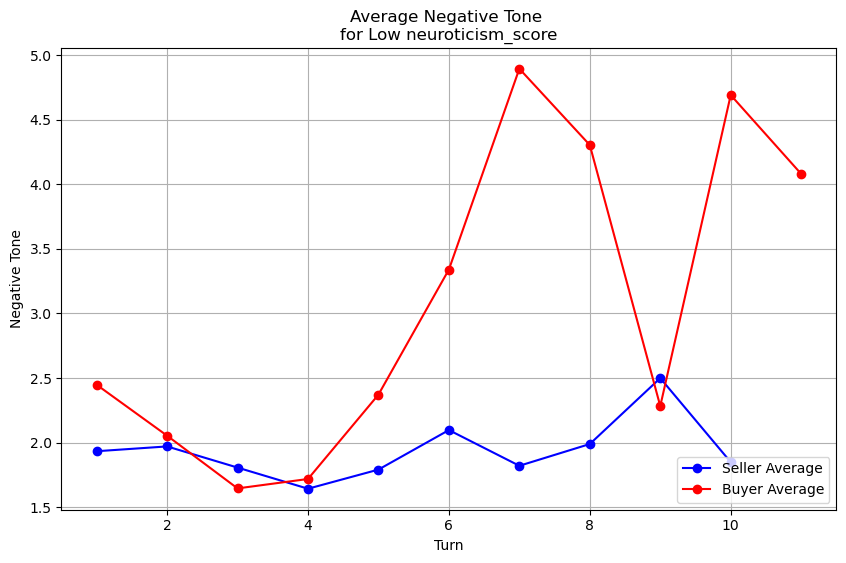

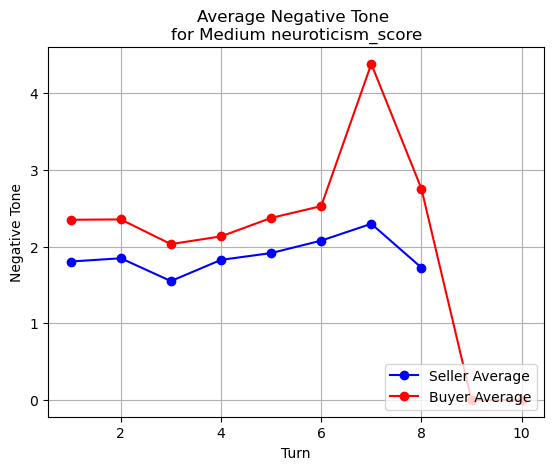

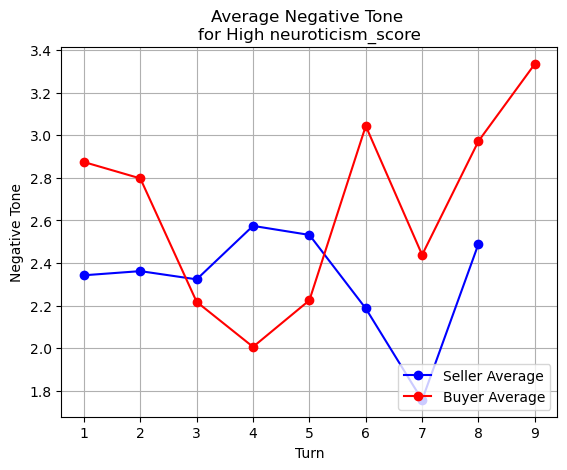

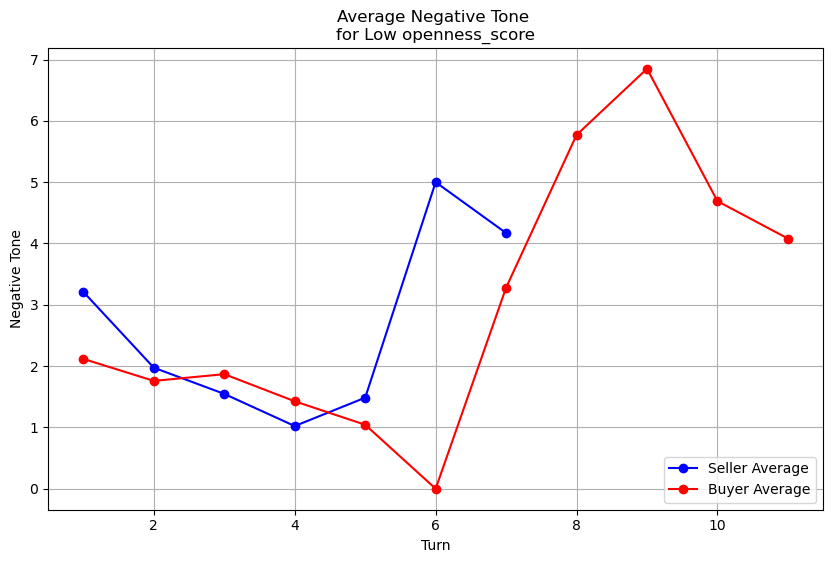

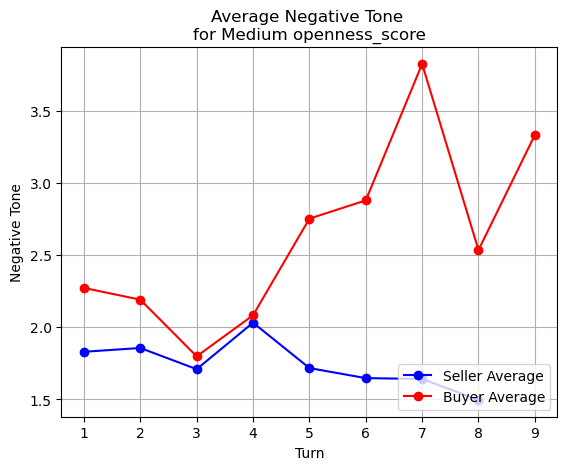

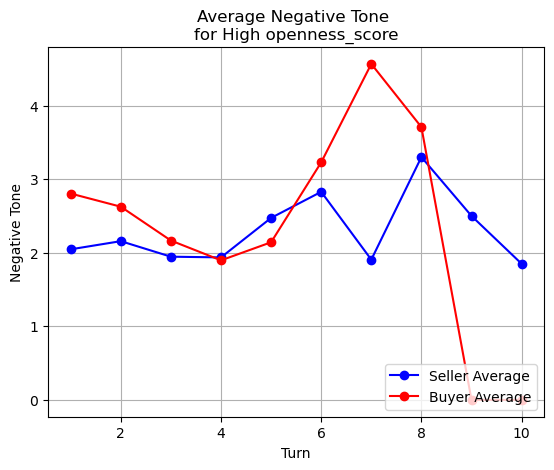

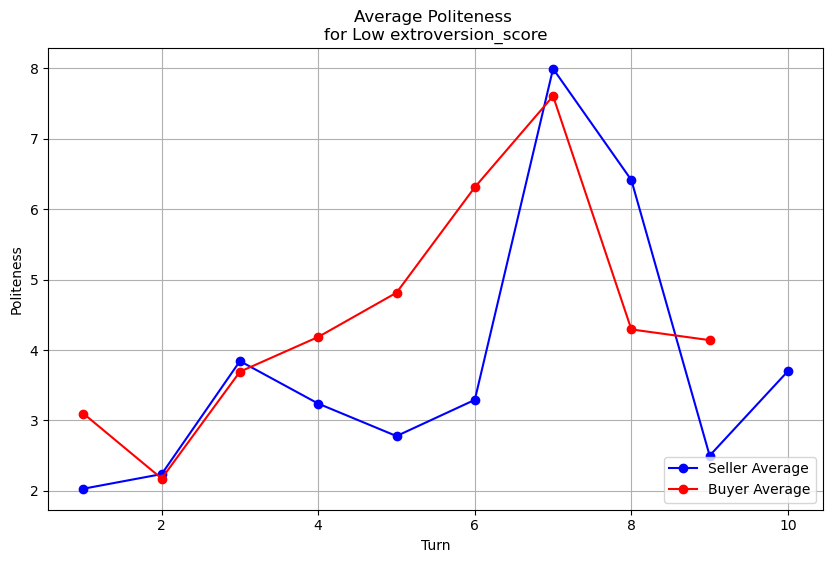

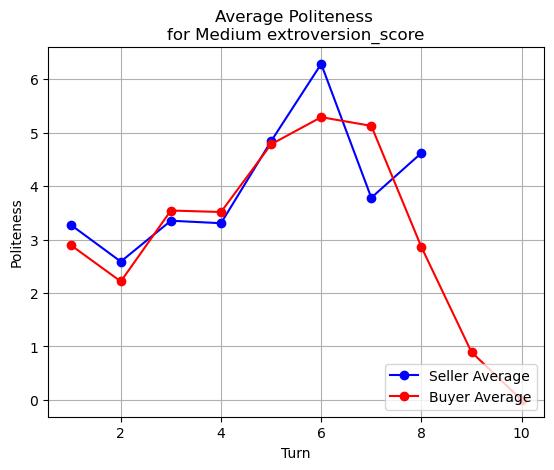

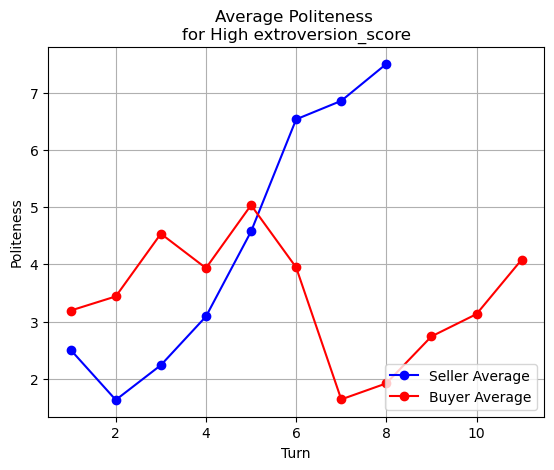

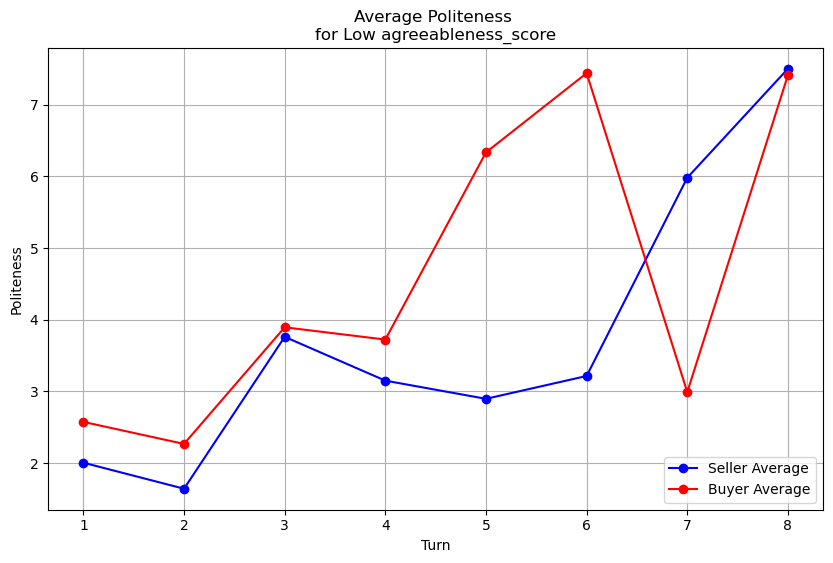

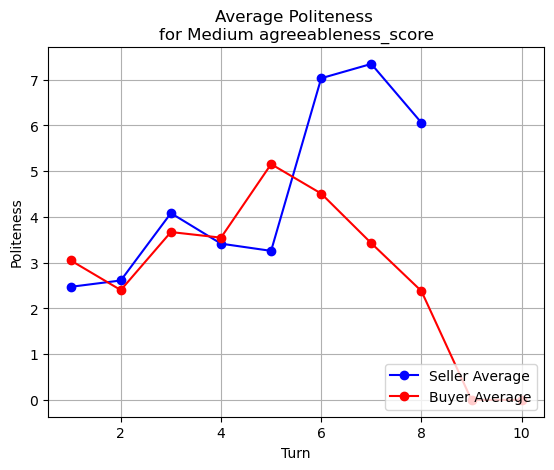

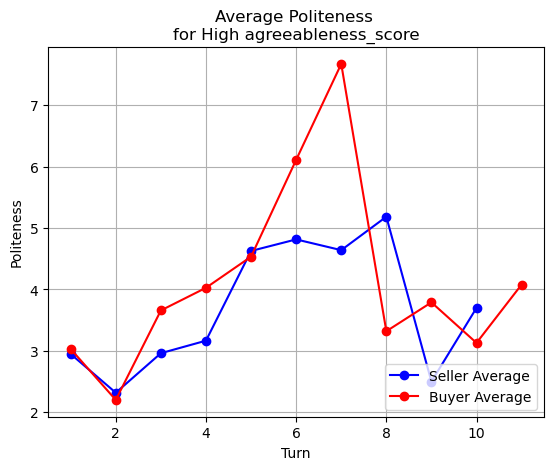

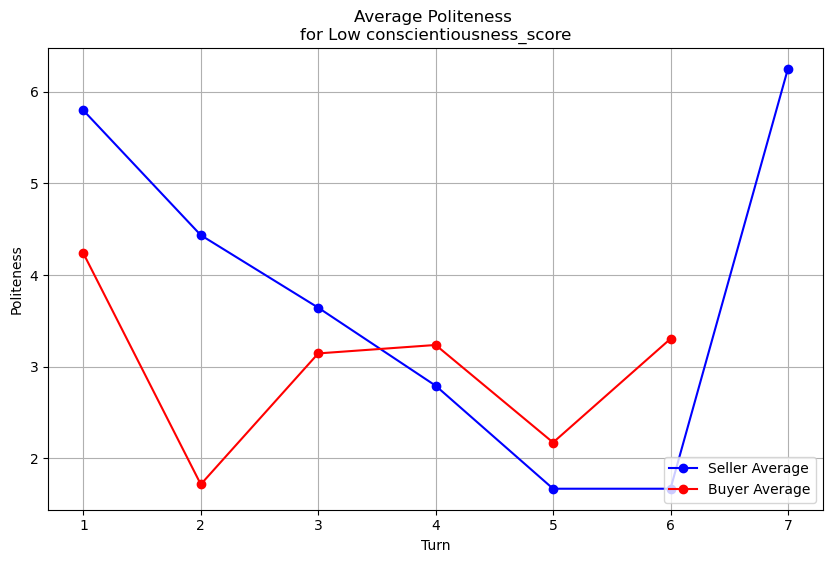

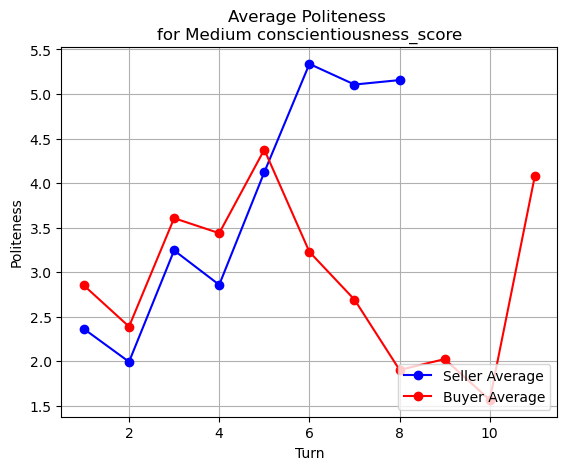

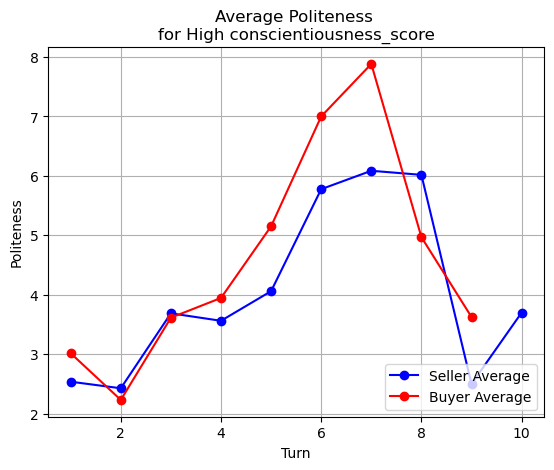

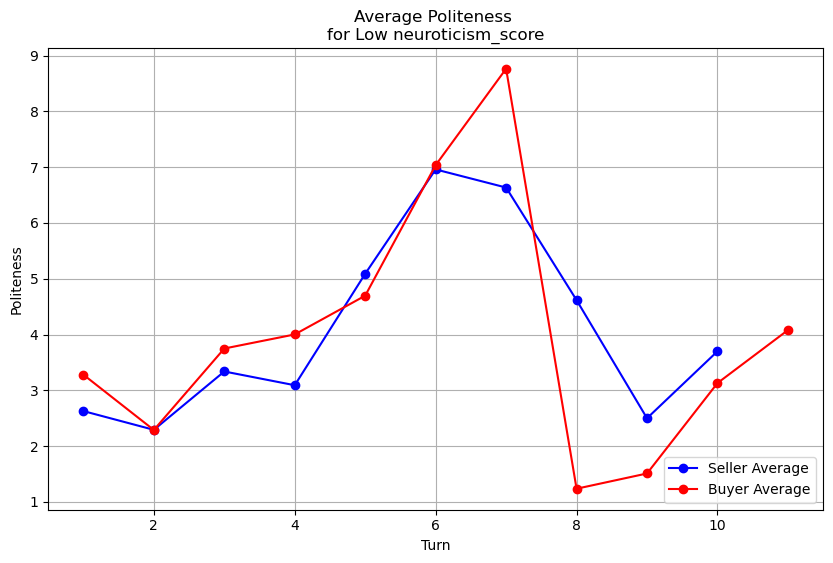

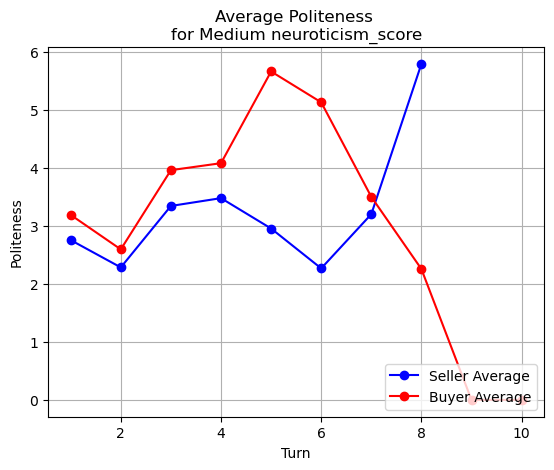

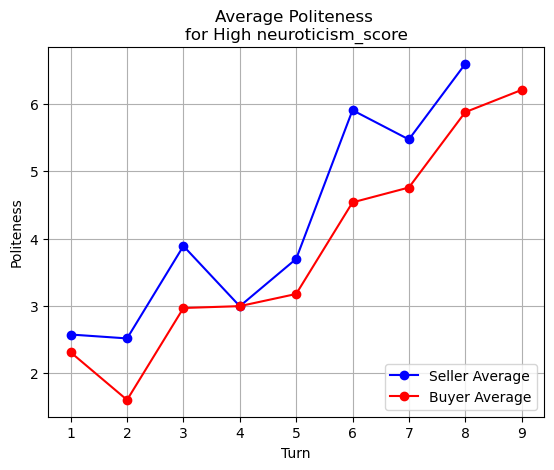

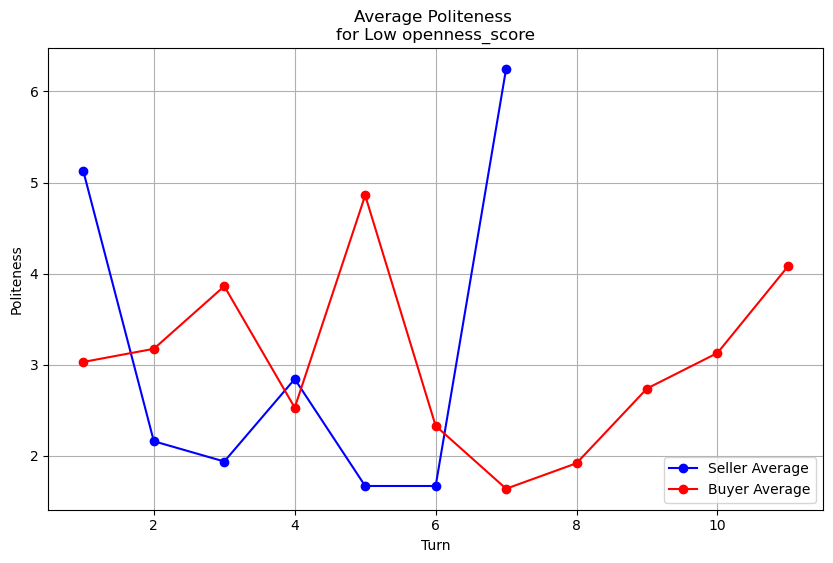

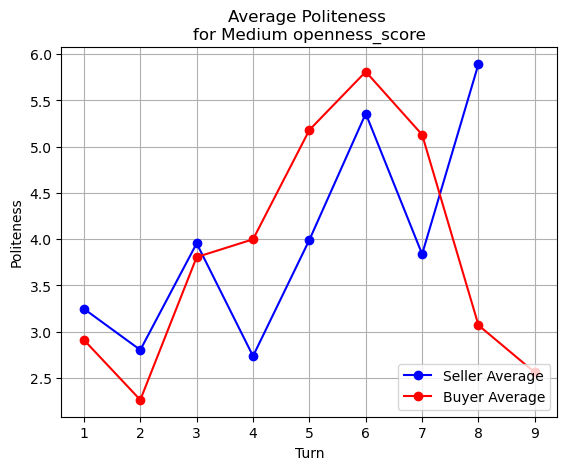

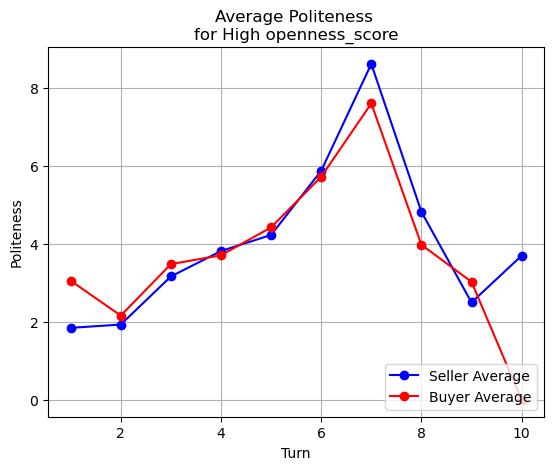

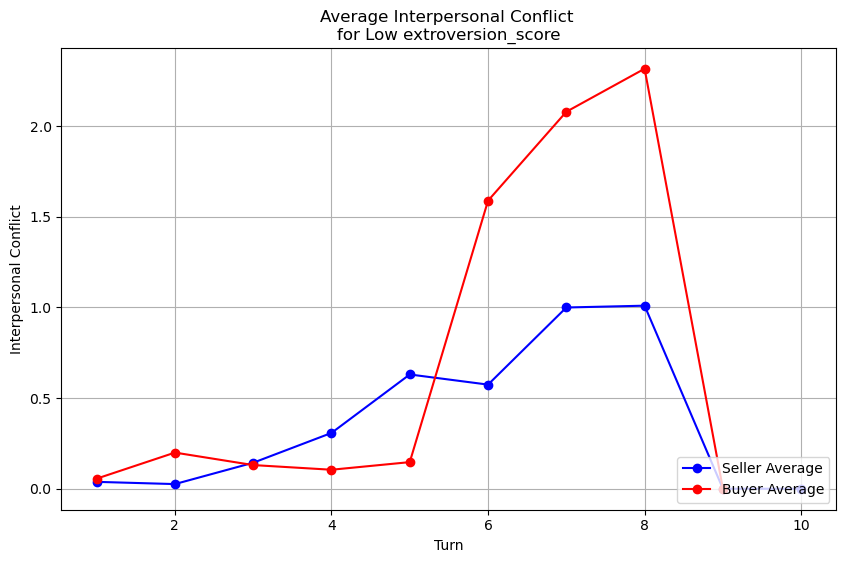

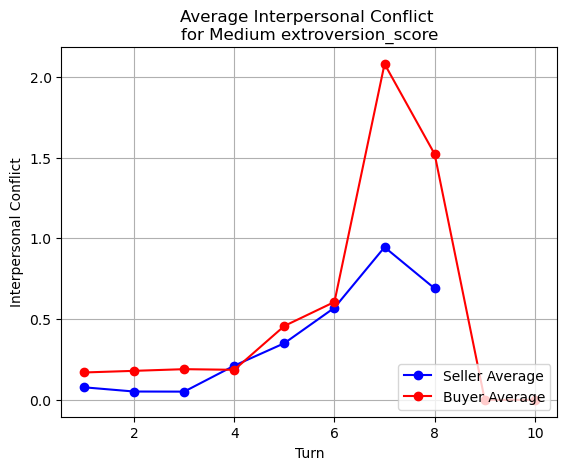

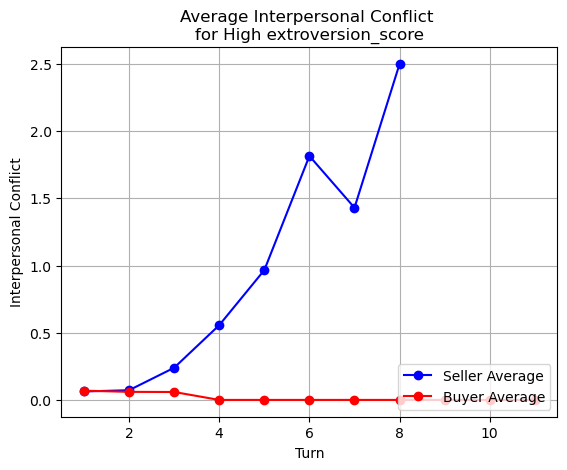

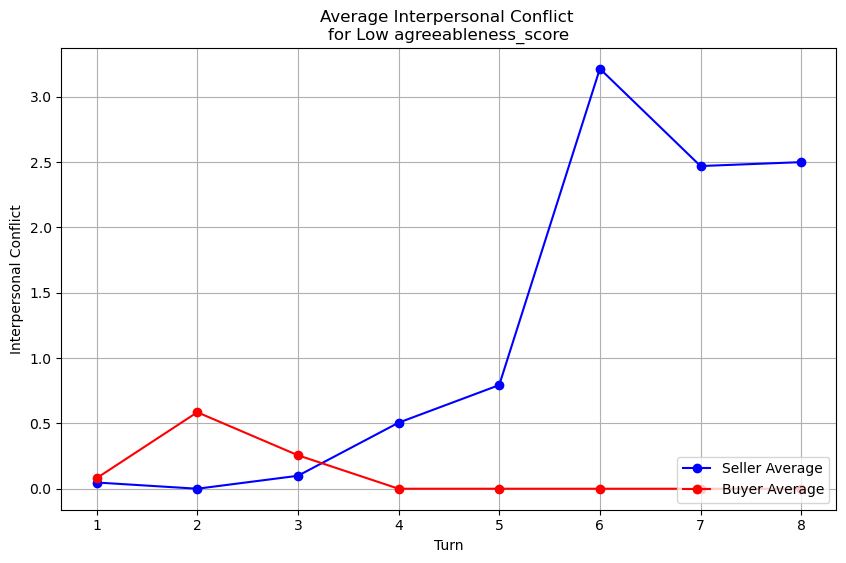

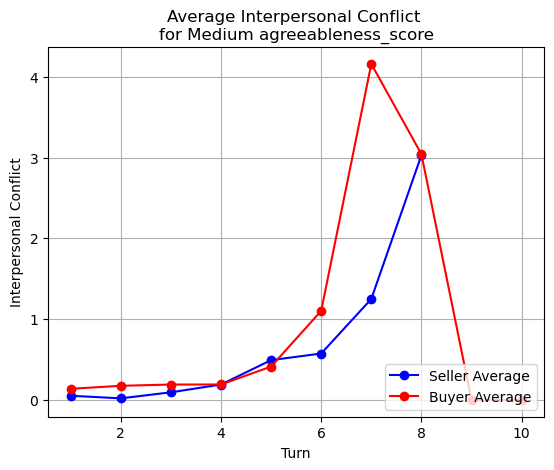

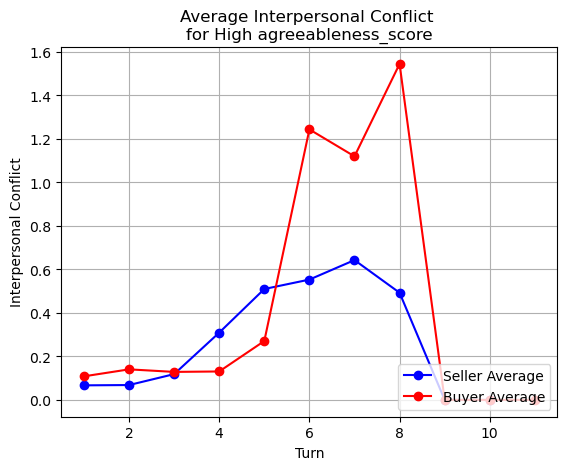

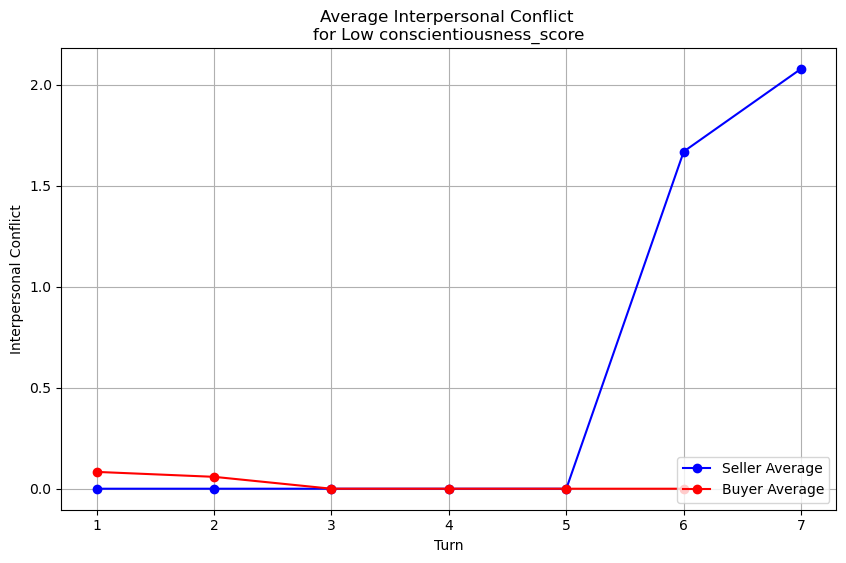

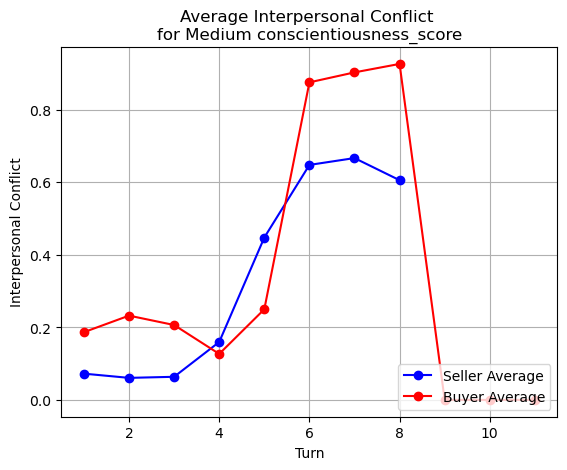

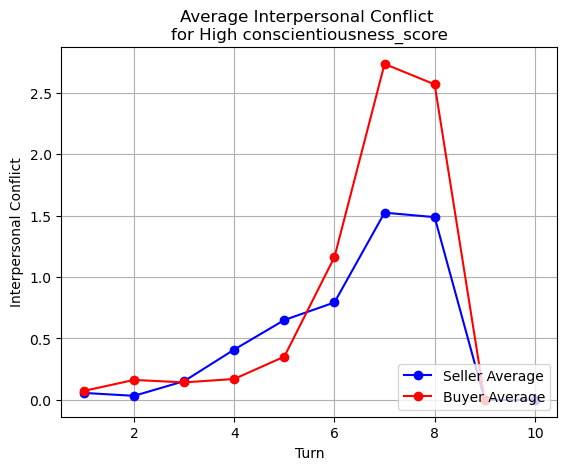

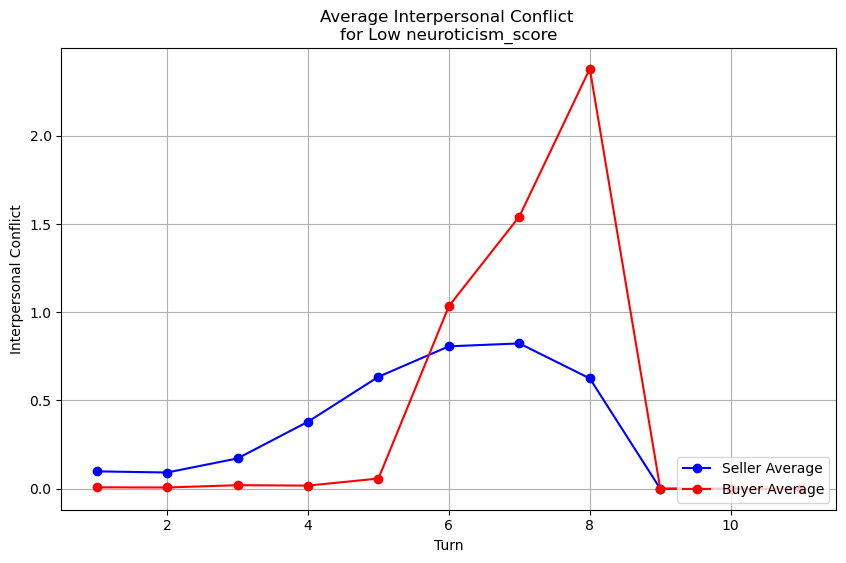

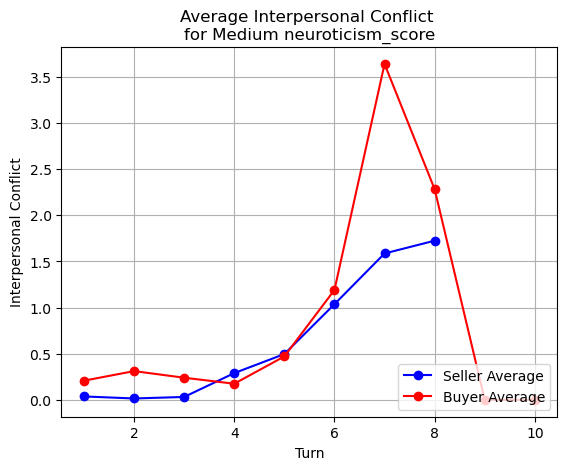

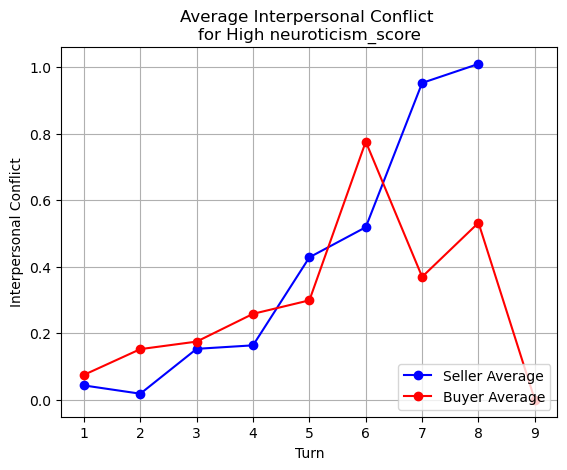

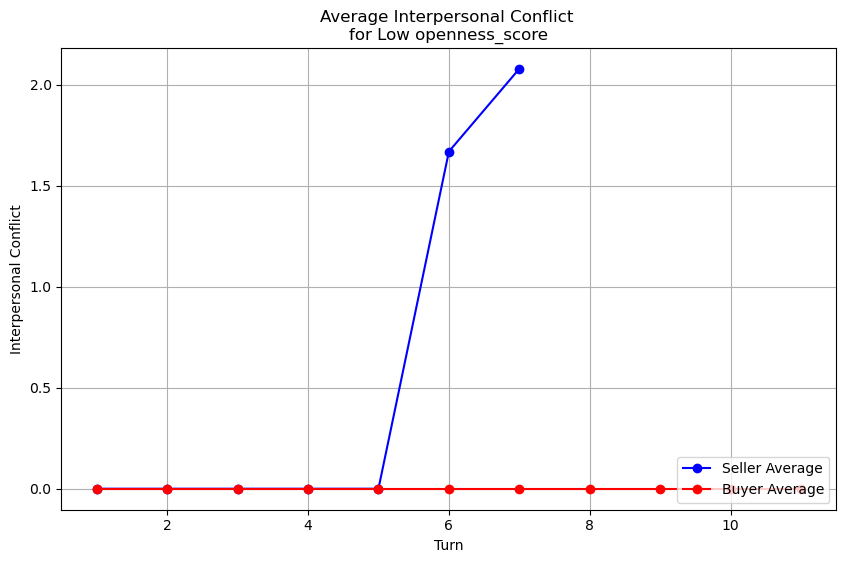

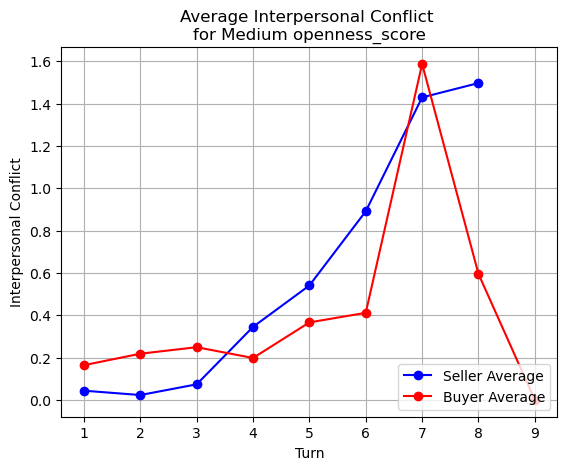

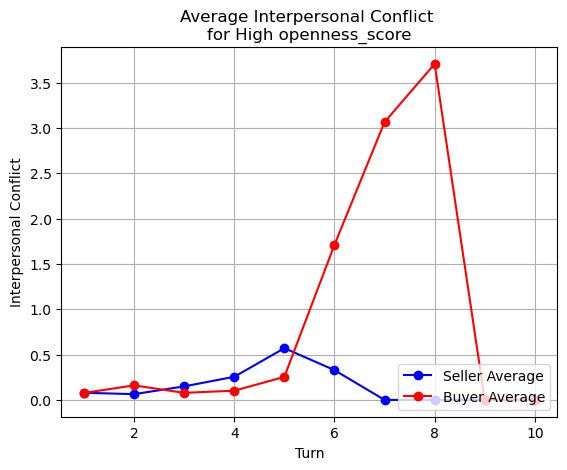

In [18]:
for category in liwc_categories.keys(): 
    plot_liwc(category, personality_scores, buyer_data, seller_data, personality_traits)
    # print(category, personality_scores)